<div style="background: linear-gradient(135deg, #0a1628 0%, #1a3a5c 50%, #0d2137 100%); padding: 50px 40px; border-radius: 20px; text-align: center; border: 3px solid #c9a84c; box-shadow: 0 10px 40px rgba(0,0,0,0.5);">

  <div style="font-size: 60px; margin-bottom: 10px;">⚓🚢</div>

  <h1 style="color: #c9a84c; font-size: 2.8em; font-weight: 900; letter-spacing: 3px; margin-bottom: 5px; text-shadow: 2px 2px 8px rgba(0,0,0,0.5);">
    TİTANİC
  </h1>

  <h2 style="color: #ffffff; font-size: 1.8em; font-weight: 600; margin-bottom: 5px;">
    Veri Ön İşleme & Özellik Mühendisliği
  </h2>

  <div style="width: 80px; height: 3px; background: #c9a84c; margin: 20px auto;"></div>

  <p style="color: #a8c8e8; font-size: 1.1em; line-height: 1.8; max-width: 700px; margin: 0 auto 20px auto;">
    EDA'da keşfettiğimiz her bulguyu adım adım bir makine öğrenmesi projesine dönüştürüyoruz.<br>
    <strong style="color: #c9a84c;">Ham veriden model-ready veriye: 17 Adımlık Yolculuk</strong>
  </p>

  <div style="background: rgba(201, 168, 76, 0.15); border: 1px solid #c9a84c; border-radius: 10px; padding: 15px 30px; display: inline-block; margin-top: 10px;">
    <span style="color: #c9a84c; font-size: 0.95em;">📚 YBS 3. Sınıf &nbsp;|&nbsp; Makine Öğrenmesi &nbsp;|&nbsp; Ders 04 &nbsp;|&nbsp; 10 Mart 2026</span>
  </div>

</div>


<div style="background: linear-gradient(90deg, #0a1628, #1a3a5c); padding: 18px 25px; border-radius: 12px; border-left: 6px solid #c9a84c; margin: 10px 0;">
  <h2 style="color: #c9a84c; margin: 0; font-size: 1.5em;">⚙️ Adım 0 — Kurulum & Veri Yükleme</h2>
  <p style="color: #a8c8e8; margin: 8px 0 0 0; font-size: 0.95em;">Her makine öğrenmesi projesine başlamadan önce kütüphaneleri yükler, veriyi okur ve ilk genel bakışı yaparız.</p>
</div>


In [33]:
# ============================================================
# 📦 GEREKLİ KÜTÜPHANELERİ YÜKLÜYORUZ
# ============================================================

# Veri işleme ve sayısal hesaplama
import pandas as pd
import numpy as np

# Görselleştirme
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Scikit-learn: Ön işleme araçları
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split

# ⚠️ imbalanced-learn (imblearn) kütüphanesi Adım 15'te ayrıca import edilecek.
# Eğer kurulu değilse terminalde şunu çalıştır:
#   pip install --upgrade imbalanced-learn

# Uyarıları kapat (temiz çıktı için)
import warnings
warnings.filterwarnings('ignore')

# Pandas gösterim ayarları
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

print("✅ Tüm kütüphaneler başarıyla yüklendi!")


✅ Tüm kütüphaneler başarıyla yüklendi!


In [34]:
# ============================================================
# 📂 VERİYİ OKUYORUZ & HAM VERİYİ SAKLIYORUZ
# ============================================================
import os

# data/ klasörünü oluştur (zaten varsa hata verme)
os.makedirs('data', exist_ok=True)

# Ham veriyi oku
df = pd.read_csv('titanic.csv')

# ---------------------------------------------------------------
# 💾 Ham veriyi data/raw_data.csv olarak kalıcı kaydet
#    → Bu dosyaya bir daha dokunmuyoruz!
#    → Tüm ön işleme adımlarında df üzerinde çalışıyoruz
# ---------------------------------------------------------------
df.to_csv('data/raw_data.csv', index=False)

print(f"✅ Veri başarıyla yüklendi.")
print(f"📐 Boyut: {df.shape[0]} satır × {df.shape[1]} sütun")
print(f"💾 Ham veri kaydedildi → data/raw_data.csv")
print()
print("İlk 5 satır:")
df.head()


✅ Veri başarıyla yüklendi.
📐 Boyut: 891 satır × 12 sütun
💾 Ham veri kaydedildi → data/raw_data.csv

İlk 5 satır:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.00,1,0,A/5 21171,7.25,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.00,1,0,PC 17599,71.28,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.00,0,0,STON/O2. 3101282,7.92,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00,1,0,113803,53.10,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.00,0,0,373450,8.05,NaN,S


In [35]:
# ============================================================
# 🔍 VERİYE GENEL BAKIŞ
# ============================================================

print("=" * 60)
print("📋 SÜTUN BİLGİLERİ (df.info())")
print("=" * 60)
df.info()

print()
print("=" * 60)
print("🔢 EKSİK VERİ ÖZETİ")
print("=" * 60)
eksik = df.isnull().sum()
eksik_oran = (df.isnull().sum() / len(df) * 100).round(1)
eksik_df = pd.DataFrame({
    'Eksik Sayı': eksik,
    'Eksik Oran (%)': eksik_oran
}).query('`Eksik Sayı` > 0').sort_values('Eksik Oran (%)', ascending=False)

print(eksik_df.to_string())
print()
print("=" * 60)
print("📊 İSTATİSTİKSEL ÖZET (Sayısal Değişkenler)")
print("=" * 60)
df.describe().round(2)


📋 SÜTUN BİLGİLERİ (df.info())
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

🔢 EKSİK VERİ ÖZETİ
          Eksik Sayı  Eksik Oran (%)
Cabin            687           77.10
Age              177           19.90
Embarked           2            0.20

📊 İSTATİSTİKSEL ÖZET (Sayısal Değişkenler)


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


<div style="background: linear-gradient(90deg, #0a1628, #1a3a5c); padding: 18px 25px; border-radius: 12px; border-left: 6px solid #c9a84c; margin: 10px 0;">
  <h2 style="color: #c9a84c; margin: 0; font-size: 1.5em;">🔁 Adım 1 — Duplicate (Tekrarlayan) Kayıt Kontrolü</h2>
  <p style="color: #d0e4f7; margin: 8px 0 0 0; font-size: 0.95em;">Veri ön işlemenin ilk standardı: Aynı yolcunun iki kez girilip girilmediğini kontrol et.</p>
</div>

<div style="background: #0d1f35; border-radius: 10px; padding: 20px 25px; border: 1px solid #1e4d7b; color: #d0e4f7;">

  <h3 style="color: #a8c8e8; margin-top: 0;">💡 Neden Önemli?</h3>

  <p style="color: #d0e4f7;">Gerçek projelerde aynı müşteri iki kez sisteme girmiş olabilir. Eğer bu kayıt hem <strong style="color: #f0e6c8;">train</strong> hem <strong style="color: #f0e6c8;">test</strong> setine düşerse:</p>

  <ul style="color: #d0e4f7; line-height: 1.9; padding-left: 20px;">
    <li>Model aslında gördüğü bir veriyi <em>"tahmin ediyor"</em> gibi davranır</li>
    <li>Doğruluk şişer, ama bu <strong style="color: #f4c430;">aldatıcı</strong> bir doğruluktur</li>
  </ul>

  <p style="color: #d0e4f7;"><strong style="color: #f0e6c8;">Titanic'te tekrar eden kayıt yok</strong> — bu durumu görmek de öğretici:</p>

  <blockquote style="border-left: 3px solid #c9a84c; margin: 0; padding: 8px 15px; background: rgba(201,168,76,0.08); border-radius: 0 6px 6px 0;">
    <em style="color: #c9a84c;">"Kontrol et, temizse geç."</em>
  </blockquote>

</div>


In [36]:
# ============================================================
# 🔁 ADIM 1 — DUPLICATE KAYIT KONTROLÜ
# ============================================================

# Kaç tane duplicate satır var?
duplicate_sayisi = df.duplicated().sum()

print(f"🔍 Toplam satır sayısı   : {len(df)}")
print(f"🔁 Tekrarlayan kayıt    : {duplicate_sayisi}")

if duplicate_sayisi == 0:
    print()
    print("✅ Harika! Hiç tekrarlayan kayıt yok. Devam edebiliriz.")
else:
    # Eğer duplicate varsa temizle
    print(f"⚠️  {duplicate_sayisi} duplicate kayıt bulundu — temizleniyor...")
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"✅ Temizlendi. Yeni boyut: {df.shape}")

# ============================================================
# 🎓 DERS NOTU: df.duplicated() her satır için True/False döner
# .sum() ile True sayısını (yani duplicate kayıt adedini) alırız
# ============================================================


🔍 Toplam satır sayısı   : 891
🔁 Tekrarlayan kayıt    : 0

✅ Harika! Hiç tekrarlayan kayıt yok. Devam edebiliriz.


<div style="background: linear-gradient(90deg, #0a1628, #1a3a5c); padding: 18px 25px; border-radius: 12px; border-left: 6px solid #c9a84c; margin: 10px 0;">
  <h2 style="color: #c9a84c; margin: 0; font-size: 1.5em;">🎯 Adım 2 — Hedef Değişken & Sınıf Dengesizliği</h2>
  <p style="color: #d0e4f7; margin: 8px 0 0 0; font-size: 0.95em;">Makine öğrenmesinde her şeyin merkezinde <strong style="color:#f0e6c8;">hedef değişken</strong> bulunur. Onu tanımadan modele geçemeyiz.</p>
</div>

<div style="background: #0d1f35; border-radius: 10px; padding: 22px 25px; border: 1px solid #1e4d7b; color: #d0e4f7;">

  <h3 style="color: #a8c8e8; margin-top: 0;">🧠 Temel Kavramlar</h3>

  <table style="width:100%; border-collapse: collapse; font-size: 0.95em;">
    <tr style="background: rgba(201,168,76,0.15);">
      <th style="color: #c9a84c; padding: 8px 12px; text-align: left; border-bottom: 1px solid #1e4d7b;">Kavram</th>
      <th style="color: #c9a84c; padding: 8px 12px; text-align: left; border-bottom: 1px solid #1e4d7b;">Açıklama</th>
    </tr>
    <tr>
      <td style="padding: 8px 12px; color: #f0e6c8; font-weight: bold;">Hedef Değişken</td>
      <td style="padding: 8px 12px; color: #d0e4f7;">Tahmin etmek istediğimiz sütun → <code style="background:#1e4d7b; padding:2px 6px; border-radius:4px;">Survived</code></td>
    </tr>
    <tr style="background: rgba(255,255,255,0.03);">
      <td style="padding: 8px 12px; color: #f0e6c8; font-weight: bold;">Sınıf Dengesizliği</td>
      <td style="padding: 8px 12px; color: #d0e4f7;">Bir sınıfın diğerinden çok daha fazla örneğe sahip olması</td>
    </tr>
    <tr>
      <td style="padding: 8px 12px; color: #f0e6c8; font-weight: bold;">Naive Model</td>
      <td style="padding: 8px 12px; color: #d0e4f7;">Hep çoğunluk sınıfını tahmin eden "tembel" model → %62 doğruluk ama işe yaramaz!</td>
    </tr>
  </table>

  <div style="margin-top: 18px; background: rgba(244, 196, 48, 0.1); border: 1px solid #f4c430; border-radius: 8px; padding: 12px 18px;">
    <p style="margin: 0; color: #f4c430; font-weight: bold;">⚠️ Kritik Soru</p>
    <p style="margin: 6px 0 0 0; color: #d0e4f7;">Eğer model <em>herkesi ölmüş</em> tahmin ederse doğruluğu ne olur?<br>
    <strong style="color:#f0e6c8;">%61.6!</strong> — Ama bu model hiçbir kurtulanı bulamaz. <em>Accuracy tek başına yeterli değildir.</em></p>
  </div>

</div>


In [37]:
# ============================================================
# 🎯 ADIM 2 — HEDEF DEĞİŞKEN & SINIF DENGESİZLİĞİ
# ============================================================

# Sınıf dağılımını sayı ve yüzde olarak göster
sinif_dagilimlari = df['Survived'].value_counts()
sinif_oran = df['Survived'].value_counts(normalize=True) * 100

print("=" * 45)
print("🎯 SURVIVED SÜTUNU — SINIF DAĞILIMI")
print("=" * 45)
print(f"  0 = Hayatta Kalmadı : {sinif_dagilimlari[0]:>4} kişi  (%{sinif_oran[0]:.1f})")
print(f"  1 = Hayatta Kaldı   : {sinif_dagilimlari[1]:>4} kişi  (%{sinif_oran[1]:.1f})")
print(f"  Toplam              : {len(df):>4} kişi")
print()

# Sınıf oranı farkı
fark = sinif_oran[0] - sinif_oran[1]
print(f"  ⚖️  Oran farkı       : %{fark:.1f}")
if fark > 15:
    print("  ⚠️  DİKKAT: Belirgin sınıf dengesizliği var!")
else:
    print("  ✅ Denge kabul edilebilir seviyede.")


🎯 SURVIVED SÜTUNU — SINIF DAĞILIMI
  0 = Hayatta Kalmadı :  549 kişi  (%61.6)
  1 = Hayatta Kaldı   :  342 kişi  (%38.4)
  Toplam              :  891 kişi

  ⚖️  Oran farkı       : %23.2
  ⚠️  DİKKAT: Belirgin sınıf dengesizliği var!


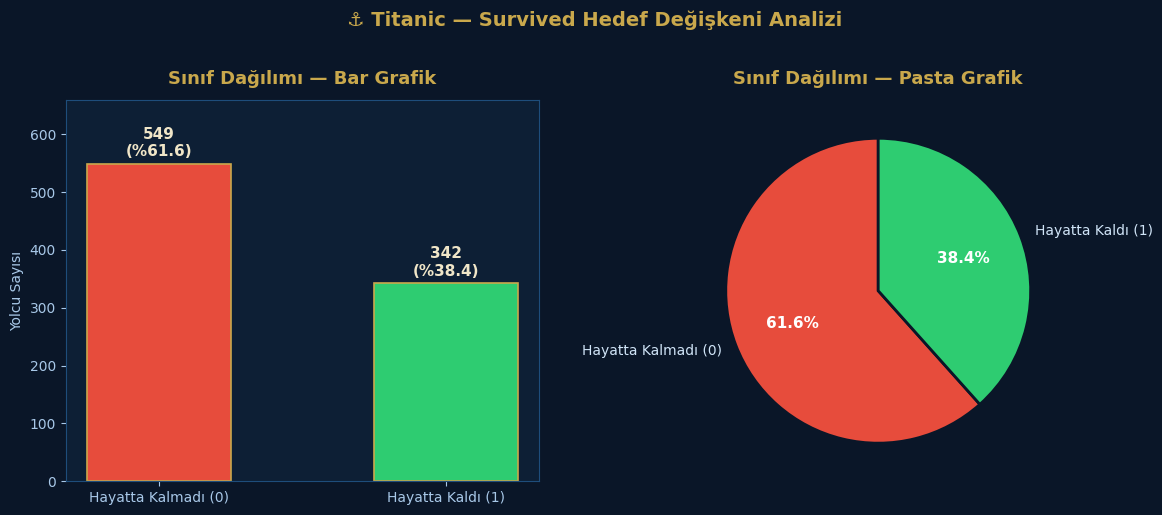


💡 Yorumlama: %61.6 vs %38.4 → Belirgin sınıf dengesizliği.
   Bu yüzden Adım 15'te Resampling tekniklerini öğreneceğiz.


In [38]:
# ============================================================
# 📊 GÖRSELLEŞTİRME — SINIF DENGESİZLİĞİ
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('#0a1628')

renkler = ['#e74c3c', '#2ecc71']  # Kırmızı = ölüm, Yeşil = kurtuluş
etiketler = ['Hayatta Kalmadı (0)', 'Hayatta Kaldı (1)']
degerler = [sinif_dagilimlari[0], sinif_dagilimlari[1]]

# --- Sol: Bar Grafik ---
ax1 = axes[0]
ax1.set_facecolor('#0d1f35')
barlar = ax1.bar(etiketler, degerler, color=renkler, width=0.5,
                  edgecolor='#c9a84c', linewidth=1.2)

# Her çubuğun üstüne değer yaz
for bar, val, oran in zip(barlar, degerler, [sinif_oran[0], sinif_oran[1]]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
             f'{val}\n(%{oran:.1f})', ha='center', va='bottom',
             color='#f0e6c8', fontsize=11, fontweight='bold')

ax1.set_title('Sınıf Dağılımı — Bar Grafik', color='#c9a84c', fontsize=13, fontweight='bold', pad=12)
ax1.set_ylabel('Yolcu Sayısı', color='#a8c8e8', fontsize=10)
ax1.tick_params(colors='#a8c8e8')
ax1.spines[:].set_color('#1e4d7b')
ax1.set_ylim(0, max(degerler) * 1.2)
for spine in ax1.spines.values():
    spine.set_edgecolor('#1e4d7b')

# --- Sağ: Pasta Grafik ---
ax2 = axes[1]
ax2.set_facecolor('#0d1f35')
wedges, texts, autotexts = ax2.pie(
    degerler,
    labels=etiketler,
    colors=renkler,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': '#0a1628', 'linewidth': 2}
)
for text in texts:
    text.set_color('#d0e4f7')
    text.set_fontsize(10)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

ax2.set_title('Sınıf Dağılımı — Pasta Grafik', color='#c9a84c', fontsize=13, fontweight='bold', pad=12)

plt.suptitle('⚓ Titanic — Survived Hedef Değişkeni Analizi',
             color='#c9a84c', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print()
print("💡 Yorumlama: %61.6 vs %38.4 → Belirgin sınıf dengesizliği.")
print("   Bu yüzden Adım 15'te Resampling tekniklerini öğreneceğiz.")


<div style="background: linear-gradient(90deg, #0a1628, #1a3a5c); padding: 18px 25px; border-radius: 12px; border-left: 6px solid #c9a84c; margin: 10px 0;">
  <h2 style="color: #c9a84c; margin: 0; font-size: 1.5em;">🗑️ Adım 3 — Gereksiz Sütunları Tanımlama ve Düşürme</h2>
  <p style="color: #d0e4f7; margin: 8px 0 0 0; font-size: 0.95em;">Her sütun bilgi taşımaz. Gürültülü ya da anlamsız sütunlar modeli olumsuz etkiler — önce tanımla, sonra düşür.</p>
</div>

<div style="background: #0d1f35; border-radius: 10px; padding: 22px 25px; border: 1px solid #1e4d7b; color: #d0e4f7; margin-top: 10px;">

  <h3 style="color: #a8c8e8; margin-top: 0;">🔍 Hangi Sütunlar Neden Düşürülür?</h3>

  <table style="width:100%; border-collapse: collapse; font-size: 0.95em; margin-bottom: 16px;">
    <tr style="background: rgba(201,168,76,0.15);">
      <th style="color: #c9a84c; padding: 8px 12px; text-align: left; border-bottom: 1px solid #1e4d7b;">Sütun</th>
      <th style="color: #c9a84c; padding: 8px 12px; text-align: left; border-bottom: 1px solid #1e4d7b;">Neden Düşürülür?</th>
      <th style="color: #c9a84c; padding: 8px 12px; text-align: left; border-bottom: 1px solid #1e4d7b;">Karar</th>
    </tr>
    <tr>
      <td style="padding: 8px 12px; color: #f0e6c8; font-weight: bold;">PassengerId</td>
      <td style="padding: 8px 12px; color: #d0e4f7;">Sadece sıra numarası — ML için sıfır bilgi içeriği</td>
      <td style="padding: 8px 12px; color: #e74c3c; font-weight: bold;">❌ Düşür</td>
    </tr>
    <tr style="background: rgba(255,255,255,0.03);">
      <td style="padding: 8px 12px; color: #f0e6c8; font-weight: bold;">Ticket</td>
      <td style="padding: 8px 12px; color: #d0e4f7;">Yüzlerce benzersiz değer (yüksek kardinalite), düzensiz format</td>
      <td style="padding: 8px 12px; color: #e74c3c; font-weight: bold;">❌ Düşür</td>
    </tr>
    <tr>
      <td style="padding: 8px 12px; color: #f0e6c8; font-weight: bold;">Name</td>
      <td style="padding: 8px 12px; color: #d0e4f7;">Ham halde anlamsız — ama içinden <strong style="color:#f4c430;">unvan (Title)</strong> çıkarabiliriz!</td>
      <td style="padding: 8px 12px; color: #f4c430; font-weight: bold;">⏳ Adım 7 sonra düşür</td>
    </tr>
  </table>

  <div style="background: rgba(46, 204, 113, 0.08); border: 1px solid #2ecc71; border-radius: 8px; padding: 12px 18px;">
    <p style="margin: 0; color: #2ecc71; font-weight: bold;">💡 Kardinalite Nedir?</p>
    <p style="margin: 6px 0 0 0; color: #d0e4f7;">Bir kategorik değişkendeki <strong style="color:#f0e6c8;">benzersiz değer sayısı</strong>na kardinalite denir.<br>
    Yüksek kardinalite → Model ezberler, genelleşemez → <strong style="color:#e74c3c;">Overfitting riski!</strong></p>
  </div>

</div>


In [39]:
# ============================================================
# 🗑️ ADIM 3 — GEREKSİZ SÜTUNLARI TANIMLAMA
# ============================================================

print("📊 Ticket sütunundaki benzersiz değer sayısı (Kardinalite):")
print(f"   Ticket : {df['Ticket'].nunique()} benzersiz değer / {len(df)} satır")
print(f"   Name   : {df['Name'].nunique()} benzersiz değer / {len(df)} satır")
print(f"   PassengerId : {df['PassengerId'].nunique()} benzersiz değer (= her satır farklı)")
print()
print("📋 Ticket sütunundan ilk 10 değer:")
print(df['Ticket'].head(10).values)
print()
print("💡 Ticket sütununda hem sayı hem harf karışık, hiçbir düzenli yapı yok.")
print("   Bu sütundan anlamlı bilgi çıkarmak çok zor → Düşürüyoruz.")


📊 Ticket sütunundaki benzersiz değer sayısı (Kardinalite):
   Ticket : 681 benzersiz değer / 891 satır
   Name   : 891 benzersiz değer / 891 satır
   PassengerId : 891 benzersiz değer (= her satır farklı)

📋 Ticket sütunundan ilk 10 değer:
['A/5 21171' 'PC 17599' 'STON/O2. 3101282' '113803' '373450' '330877'
 '17463' '349909' '347742' '237736']

💡 Ticket sütununda hem sayı hem harf karışık, hiçbir düzenli yapı yok.
   Bu sütundan anlamlı bilgi çıkarmak çok zor → Düşürüyoruz.


In [40]:
# ============================================================
# 🗑️ GEREKSİZ SÜTUNLARI DÜŞÜRME
# ============================================================

# Düşürmeden önce sütun listesini yazdır
print("📋 Düşürmeden önce sütunlar:")
print(list(df.columns))
print()

# PassengerId ve Ticket'ı düşür
# Name sütununu KORUYORUZ → Adım 7'de unvan (Title) çıkaracağız
df = df.drop(columns=['PassengerId', 'Ticket'])

print("✅ PassengerId ve Ticket düşürüldü.")
print()
print("📋 Düşürdükten sonra sütunlar:")
print(list(df.columns))
print()
print(f"📐 Yeni boyut: {df.shape[0]} satır × {df.shape[1]} sütun")

# ============================================================
# 🎓 DERS NOTU:
# drop(columns=[...]) → sütun bazında silme
# inplace=True yerine df = df.drop(...) kullanmak daha güvenli
# Ham veri her zaman → data/raw_data.csv'de güvende
# ============================================================


📋 Düşürmeden önce sütunlar:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

✅ PassengerId ve Ticket düşürüldü.

📋 Düşürdükten sonra sütunlar:
['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin', 'Embarked']

📐 Yeni boyut: 891 satır × 10 sütun


<div style="background: linear-gradient(90deg, #0a1628, #1a3a5c); padding: 18px 25px; border-radius: 12px; border-left: 6px solid #c9a84c; margin: 10px 0;">
  <h2 style="color: #c9a84c; margin: 0; font-size: 1.5em;">🔧 Adım 4 — Eksik Veri: Embarked (Kolay Senaryo)</h2>
  <p style="color: #d0e4f7; margin: 8px 0 0 0; font-size: 0.95em;">Sadece <strong style="color:#f0e6c8;">2 satır</strong> eksik. "Eksik veriden korkmayın — önce miktarına bakın!"</p>
</div>

<div style="background: #0d1f35; border-radius: 10px; padding: 22px 25px; border: 1px solid #1e4d7b; color: #d0e4f7; margin-top: 10px;">

  <h3 style="color: #a8c8e8; margin-top: 0;">🧭 Strateji: Mode ile Doldurma</h3>

  <p style="color: #d0e4f7;">Embarked sütunu yolcunun hangi limandan bindiğini gösterir: <strong style="color:#f0e6c8;">C</strong> (Cherbourg), <strong style="color:#f0e6c8;">Q</strong> (Queenstown), <strong style="color:#f0e6c8;">S</strong> (Southampton).</p>

  <table style="width:100%; border-collapse: collapse; font-size: 0.95em; margin: 14px 0;">
    <tr style="background: rgba(201,168,76,0.15);">
      <th style="color: #c9a84c; padding: 8px 12px; text-align: left; border-bottom: 1px solid #1e4d7b;">Yöntem</th>
      <th style="color: #c9a84c; padding: 8px 12px; text-align: left; border-bottom: 1px solid #1e4d7b;">Ne Zaman Kullanılır?</th>
      <th style="color: #c9a84c; padding: 8px 12px; text-align: left; border-bottom: 1px solid #1e4d7b;">Bu Adımdaki Seçim</th>
    </tr>
    <tr>
      <td style="padding: 8px 12px; color: #f0e6c8;">Mean (Ortalama)</td>
      <td style="padding: 8px 12px; color: #d0e4f7;">Sayısal, normal dağılım</td>
      <td style="padding: 8px 12px; color: #888;">—</td>
    </tr>
    <tr style="background: rgba(255,255,255,0.03);">
      <td style="padding: 8px 12px; color: #f0e6c8;">Median (Medyan)</td>
      <td style="padding: 8px 12px; color: #d0e4f7;">Sayısal, aykırı değer var</td>
      <td style="padding: 8px 12px; color: #888;">—</td>
    </tr>
    <tr>
      <td style="padding: 8px 12px; color: #f0e6c8; font-weight: bold;">Mode (Mod)</td>
      <td style="padding: 8px 12px; color: #d0e4f7;">Kategorik değişken ✅</td>
      <td style="padding: 8px 12px; color: #2ecc71; font-weight: bold;">✅ Seçildi → 'S'</td>
    </tr>
  </table>

  <div style="background: rgba(46,204,113,0.08); border: 1px solid #2ecc71; border-radius: 8px; padding: 10px 16px;">
    <p style="margin: 0; color: #2ecc71; font-weight: bold;">💡 Altın Kural</p>
    <p style="margin: 5px 0 0 0; color: #d0e4f7;">Eksik veri çok azsa (%1-2) → en basit yöntem yeterlidir. Karmaşık yöntemler bu durumda fark yaratmaz.</p>
  </div>

</div>


In [41]:
# ============================================================
# 🔧 ADIM 4 — EKSİK VERİ: EMBARKED
# ============================================================

print("📍 Embarked sütunu mevcut durumu:")
print(f"   Eksik satır sayısı : {df['Embarked'].isnull().sum()}")
print(f"   Değer dağılımı     :")
print(df['Embarked'].value_counts(dropna=False).to_string())
print()

# En sık görülen değer (mod) → 'S' (Southampton)
mod_degeri = df['Embarked'].mode()[0]
print(f"   Mode (En sık liman): '{mod_degeri}' → %{(df['Embarked'] == mod_degeri).mean()*100:.1f} oranında")
print()

# Eksik satırları mod ile doldur
df['Embarked'] = df['Embarked'].fillna(mod_degeri)

print(f"✅ Embarked dolduruldu. Kalan eksik: {df['Embarked'].isnull().sum()}")

# ============================================================
# 🎓 DERS NOTU:
# .mode() → en sık görülen değeri Series olarak döner
# [0]     → Series'in ilk elemanını alırız (birden fazla mod olabilir)
# fillna() → eksik değerlerin yerine belirtilen değeri yazar
# ============================================================


📍 Embarked sütunu mevcut durumu:
   Eksik satır sayısı : 2
   Değer dağılımı     :
Embarked
S      644
C      168
Q       77
NaN      2

   Mode (En sık liman): 'S' → %72.3 oranında

✅ Embarked dolduruldu. Kalan eksik: 0


<div style="background: linear-gradient(90deg, #0a1628, #1a3a5c); padding: 18px 25px; border-radius: 12px; border-left: 6px solid #c9a84c; margin: 10px 0;">
  <h2 style="color: #c9a84c; margin: 0; font-size: 1.5em;">🧠 Adım 5 — Eksik Veri: Age (Akıllı Imputation)</h2>
  <p style="color: #d0e4f7; margin: 8px 0 0 0; font-size: 0.95em;"><strong style="color:#f0e6c8;">%19.9 eksik</strong> (177 satır) — Genel medyan kaba çözümdür. EDA bulgusunu kullanarak çok daha akıllı doldurabiliriz.</p>
</div>

<div style="background: #0d1f35; border-radius: 10px; padding: 22px 25px; border: 1px solid #1e4d7b; color: #d0e4f7; margin-top: 10px;">

  <h3 style="color: #a8c8e8; margin-top: 0;">🆚 Kaba vs Akıllı Doldurma</h3>

  <table style="width:100%; border-collapse: separate; border-spacing: 10px; margin-bottom: 6px;">
    <tr>
      <td style="background: rgba(231,76,60,0.1); border: 1px solid #e74c3c; border-radius: 8px; padding: 14px; width:50%; vertical-align:top;">
        <p style="margin: 0; color: #e74c3c; font-weight: bold;">❌ Kaba Yöntem</p>
        <p style="margin: 8px 0; color: #d0e4f7; font-size: 0.9em;">Tüm eksikleri <strong style="color:#f0e6c8;">genel medyan</strong> ile doldur (28 yaş)</p>
        <p style="margin: 0; color: #aaa; font-size: 0.85em;">Sorun: "Master" unvanlı çocuklar da 28 yaş olur!</p>
      </td>
      <td style="background: rgba(46,204,113,0.1); border: 1px solid #2ecc71; border-radius: 8px; padding: 14px; width:50%; vertical-align:top;">
        <p style="margin: 0; color: #2ecc71; font-weight: bold;">✅ Akıllı Yöntem</p>
        <p style="margin: 8px 0; color: #d0e4f7; font-size: 0.9em;"><strong style="color:#f0e6c8;">Unvan + Pclass</strong> grubu medyanı ile doldur</p>
        <p style="margin: 0; color: #a8c8e8; font-size: 0.85em;">Master + 3.Sınıf → ~5 yaş &nbsp;|&nbsp; Mr. + 1.Sınıf → ~40 yaş</p>
      </td>
    </tr>
  </table>

  <div style="background: rgba(201,168,76,0.1); border: 1px solid #c9a84c; border-radius: 8px; padding: 12px 16px; margin-top: 10px;">
    <p style="margin: 0; color: #c9a84c; font-weight: bold;">💡 EDA → Feature Engineering Bağlantısı</p>
    <p style="margin: 5px 0 0 0; color: #d0e4f7;">Bu adımda <code style="background:#1e4d7b; padding:2px 6px; border-radius:4px;">Title</code> sütununa ihtiyaç duyuyoruz. Bu yüzden önce <strong style="color:#f0e6c8;">Adım 7</strong>'deki unvan çıkarımını burada önceden uygulayıp Age'i dolduracağız.</p>
  </div>

</div>


In [42]:
# ============================================================
# 🧠 ADIM 5 — EKSİK VERİ: AGE (AKILLI IMPUTATİON)
# Önce Title çıkarımını yapalım, akıllı doldurma için gerekli
# ============================================================

print(f"⚠️  Age sütunundaki eksik sayısı: {df['Age'].isnull().sum()} ({df['Age'].isnull().mean()*100:.1f}%)")
print()

# --- Adım 5a: Geçici Title sütunu oluştur (tam haliyle Adım 7'de yapacağız) ---
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.')

# Nadir unvanları "Rare" olarak gruplandır
nadir = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr',
         'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
df['Title'] = df['Title'].replace(nadir, 'Rare')
df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

print("📛 Title dağılımı:")
print(df['Title'].value_counts().to_string())
print()

# --- Adım 5b: Kaba yöntem (sadece karşılaştırma için) ---
yas_genel_medyan = df['Age'].median()
print(f"   Genel medyan (kaba yöntem)     : {yas_genel_medyan:.1f} yaş → HERKESİN yaşı bu olur!")

# --- Adım 5c: Akıllı yöntem → Grup (Title + Pclass) medyanı ---
print()
print("📊 Title + Pclass grubu yaş medyanları (akıllı yöntem):")
grup_medyanlari = df.groupby(['Title', 'Pclass'])['Age'].median()
print(grup_medyanlari.to_string())
print()

# Eksikleri grup medyanıyla doldur
df['Age'] = df.groupby(['Title', 'Pclass'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

# Eğer hâlâ eksik kalan varsa (çok nadir grup) genel medyanla kapat
df['Age'] = df['Age'].fillna(yas_genel_medyan)

print(f"✅ Age dolduruldu. Kalan eksik: {df['Age'].isnull().sum()}")

# ============================================================
# 🎓 DERS NOTU:
# groupby().transform() → her satıra kendi grubunun değerini atar
# Bu sayede aynı DataFrame içinde işlem yaparız, merge gerekmez
# ============================================================


⚠️  Age sütunundaki eksik sayısı: 177 (19.9%)

📛 Title dağılımı:
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23

   Genel medyan (kaba yöntem)     : 28.0 yaş → HERKESİN yaşı bu olur!

📊 Title + Pclass grubu yaş medyanları (akıllı yöntem):
Title   Pclass
Master  1         4.00
        2         1.00
        3         4.00
Miss    1        30.00
        2        24.00
        3        18.00
Mr      1        40.00
        2        31.00
        3        26.00
Mrs     1        40.00
        2        32.00
        3        31.00
Rare    1        48.50
        2        46.50

✅ Age dolduruldu. Kalan eksik: 0


<div style="background: linear-gradient(90deg, #0a1628, #1a3a5c); padding: 18px 25px; border-radius: 12px; border-left: 6px solid #c9a84c; margin: 10px 0;">
  <h2 style="color: #c9a84c; margin: 0; font-size: 1.5em;">🏚️ Adım 6 — Eksik Veri: Cabin (Yüksek Eksiklik Stratejisi)</h2>
  <p style="color: #d0e4f7; margin: 8px 0 0 0; font-size: 0.95em;"><strong style="color:#e74c3c;">%77.1 eksik</strong> — Doldurmak anlamsız. Ama eksikliğin kendisi bir sinyal olabilir!</p>
</div>

<div style="background: #0d1f35; border-radius: 10px; padding: 22px 25px; border: 1px solid #1e4d7b; color: #d0e4f7; margin-top: 10px;">

  <h3 style="color: #a8c8e8; margin-top: 0;">⚡ 3 Farklı Strateji</h3>

  <table style="width:100%; border-collapse: separate; border-spacing: 8px; margin-bottom: 10px;">
    <tr>
      <td style="background: rgba(52,152,219,0.1); border: 1px solid #3498db; border-radius: 8px; padding: 12px; width:33%; vertical-align:top;">
        <p style="margin: 0; color: #3498db; font-weight: bold;">🔤 Strateji A</p>
        <p style="margin: 6px 0; color: #f0e6c8; font-weight: bold; font-size: 0.9em;">Güverte Harfi Çıkar</p>
        <p style="margin: 0; color: #d0e4f7; font-size: 0.85em;">'C85' → 'C', eksiklere 'U' (Unknown)</p>
      </td>
      <td style="background: rgba(46,204,113,0.1); border: 1px solid #2ecc71; border-radius: 8px; padding: 12px; width:33%; vertical-align:top;">
        <p style="margin: 0; color: #2ecc71; font-weight: bold;">🔢 Strateji B ✅</p>
        <p style="margin: 6px 0; color: #f0e6c8; font-weight: bold; font-size: 0.9em;">Binary Has_Cabin</p>
        <p style="margin: 0; color: #d0e4f7; font-size: 0.85em;">Cabin var=1, yok=0 → Eksiklik sinyal taşır</p>
      </td>
      <td style="background: rgba(231,76,60,0.1); border: 1px solid #e74c3c; border-radius: 8px; padding: 12px; width:33%; vertical-align:top;">
        <p style="margin: 0; color: #e74c3c; font-weight: bold;">🗑️ Strateji C</p>
        <p style="margin: 6px 0; color: #f0e6c8; font-weight: bold; font-size: 0.9em;">Tamamen Düşür</p>
        <p style="margin: 0; color: #d0e4f7; font-size: 0.85em;">Basit ama bilgi kaybı yaşanır</p>
      </td>
    </tr>
  </table>

  <div style="background: rgba(201,168,76,0.1); border: 1px solid #c9a84c; border-radius: 8px; padding: 12px 16px;">
    <p style="margin: 0; color: #c9a84c; font-weight: bold;">🔍 EDA'dan Hatırlıyoruz</p>
    <p style="margin: 5px 0 0 0; color: #d0e4f7;">Cabin sahibi olan yolcuların büyük çoğunluğu <strong style="color:#f0e6c8;">1. sınıf</strong>. Yani Cabin eksikliği aslında "3. sınıf / ekonomik yolcu" sinyali verir → <strong style="color:#2ecc71;">Strateji B tercih edilir.</strong></p>
  </div>

</div>


In [43]:
# ============================================================
# 🏚️ ADIM 6 — EKSİK VERİ: CABIN (3 STRATEJİ + KARŞILAŞTIRMA)
# ============================================================

print(f"🏚️  Cabin eksik sayısı : {df['Cabin'].isnull().sum()} / {len(df)} (%{df['Cabin'].isnull().mean()*100:.1f})")
print()

# --- STRATEJİ A: Güverte harfi çıkar ---
df['Deck'] = df['Cabin'].str[0]           # İlk harfi al (C85 → C)
df['Deck'] = df['Deck'].fillna('U')       # Eksiklere 'U' (Unknown)
print("🔤 Strateji A — Deck sütunu (güverte harfi):")
print(df['Deck'].value_counts().to_string())
print()

# --- STRATEJİ B: Binary Has_Cabin (seçilen yöntem) ---
df['Has_Cabin'] = df['Cabin'].notnull().astype(int)   # var=1, yok=0
print("🔢 Strateji B — Has_Cabin (0/1):")
print(df['Has_Cabin'].value_counts().to_string())
print()

# Has_Cabin ile hayatta kalma ilişkisini göster
print("📊 Has_Cabin → Hayatta Kalma Oranı:")
print(df.groupby('Has_Cabin')['Survived'].mean().round(3).to_string())
print("   → Cabin'i olan (1): çok daha yüksek hayatta kalma! Sinyal taşıyor ✅")
print()

# Ham Cabin sütununu ve Deck sütununu düşür (Has_Cabin yeterli)
df = df.drop(columns=['Cabin', 'Deck'])

print("✅ Cabin ve Deck düşürüldü. Has_Cabin sütunu eklendi.")
print(f"📐 Güncel boyut: {df.shape[0]} satır × {df.shape[1]} sütun")
print()

# --- EKSİK VERİ ÖZET KONTROLÜ ---
kalan_eksik = df.isnull().sum()
kalan_eksik = kalan_eksik[kalan_eksik > 0]
if len(kalan_eksik) == 0:
    print("🎉 Harika! Artık hiç eksik veri yok.")
else:
    print("⚠️  Hâlâ eksik olan sütunlar:")
    print(kalan_eksik.to_string())

# ============================================================
# 🎓 DERS NOTU:
# notnull() → değer varsa True, eksikse False döner
# astype(int) → True=1, False=0'a çevirir
# Eksikliğin kendisi bazen en güçlü feature'dır!
# ============================================================


🏚️  Cabin eksik sayısı : 687 / 891 (%77.1)

🔤 Strateji A — Deck sütunu (güverte harfi):
Deck
U    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1

🔢 Strateji B — Has_Cabin (0/1):
Has_Cabin
0    687
1    204

📊 Has_Cabin → Hayatta Kalma Oranı:
Has_Cabin
0   0.30
1   0.67
   → Cabin'i olan (1): çok daha yüksek hayatta kalma! Sinyal taşıyor ✅

✅ Cabin ve Deck düşürüldü. Has_Cabin sütunu eklendi.
📐 Güncel boyut: 891 satır × 11 sütun

🎉 Harika! Artık hiç eksik veri yok.


<div style="background: linear-gradient(90deg, #0a1628, #1a3a5c); padding: 18px 25px; border-radius: 12px; border-left: 6px solid #c9a84c; margin: 10px 0;">
  <h2 style="color: #c9a84c; margin: 0; font-size: 1.5em;">🏷️ Adım 7 — Özellik Mühendisliği: Title (Unvan) Çıkarımı</h2>
  <p style="color: #d0e4f7; margin: 8px 0 0 0; font-size: 0.95em;"><code style="background:#1e4d7b; padding:2px 6px; border-radius:4px;">Name</code> sütunu ham halde işe yaramaz — ama içinde gizlenmiş <strong style="color:#f0e6c8;">unvan (Mr., Mrs., Miss...)</strong> yaş, cinsiyet ve sosyal statü hakkında çok şey söyler.</p>
</div>

<div style="background: #0d1f35; border-radius: 10px; padding: 22px 25px; border: 1px solid #1e4d7b; color: #d0e4f7; margin-top: 10px;">

  <h3 style="color: #a8c8e8; margin-top: 0;">🔍 Ne Yapıyoruz?</h3>

  <table style="width:100%; border-collapse: collapse; font-size: 0.95em; margin-bottom: 16px;">
    <tr style="background: rgba(201,168,76,0.15);">
      <th style="color: #c9a84c; padding: 8px 12px; text-align: left; border-bottom: 1px solid #1e4d7b;">Adım</th>
      <th style="color: #c9a84c; padding: 8px 12px; text-align: left; border-bottom: 1px solid #1e4d7b;">Açıklama</th>
    </tr>
    <tr>
      <td style="padding: 8px 12px; color: #f0e6c8; font-weight: bold;">1. Regex ile çıkar</td>
      <td style="padding: 8px 12px; color: #d0e4f7;">"Braund, Mr. Owen Harris" → <strong style="color:#f4c430;">Mr</strong></td>
    </tr>
    <tr style="background: rgba(255,255,255,0.03);">
      <td style="padding: 8px 12px; color: #f0e6c8; font-weight: bold;">2. Normalize et</td>
      <td style="padding: 8px 12px; color: #d0e4f7;">Mlle → Miss &nbsp;|&nbsp; Ms → Miss &nbsp;|&nbsp; Mme → Mrs</td>
    </tr>
    <tr>
      <td style="padding: 8px 12px; color: #f0e6c8; font-weight: bold;">3. Nadir unvanları grupla</td>
      <td style="padding: 8px 12px; color: #d0e4f7;">Dr, Col, Capt, Countess... → <strong style="color:#f4c430;">Rare</strong> (az örnek → model öğrenemez)</td>
    </tr>
    <tr style="background: rgba(255,255,255,0.03);">
      <td style="padding: 8px 12px; color: #f0e6c8; font-weight: bold;">4. Name'i düşür</td>
      <td style="padding: 8px 12px; color: #d0e4f7;">Artık işimiz bitti, ham isim sütunu gereksiz</td>
    </tr>
  </table>

  <div style="background: rgba(201,168,76,0.1); border: 1px solid #c9a84c; border-radius: 8px; padding: 12px 16px;">
    <p style="margin: 0; color: #c9a84c; font-weight: bold;">💡 Not: Title sütunu Adım 5'te zaten oluşturuldu</p>
    <p style="margin: 5px 0 0 0; color: #d0e4f7;">Age imputation için önceden ihtiyaç duyduk. Bu adımda sonuçları inceleyip <code style="background:#1e4d7b; padding:2px 6px; border-radius:4px;">Name</code> sütununu düşürüyoruz.</p>
  </div>

</div>


In [44]:
# ============================================================
# 🏷️ ADIM 7 — TITLE (UNVAN) ÇIKARIMı & NAME DÜŞÜRME
# ============================================================

# Title sütunu Adım 5'te oluşturulmuştu — mevcut halini gösterelim
print("📛 Mevcut Title dağılımı:")
print(df['Title'].value_counts().to_string())
print()

# Her unvanın hayatta kalma oranını göster
print("📊 Unvana göre hayatta kalma oranı:")
title_survived = df.groupby('Title')['Survived'].agg(['mean', 'count']).round(2)
title_survived.columns = ['Hayatta Kalma Oranı', 'Kişi Sayısı']
title_survived = title_survived.sort_values('Hayatta Kalma Oranı', ascending=False)
print(title_survived.to_string())
print()

# Name sütununu artık düşürebiliriz (Title çıkarıldı, işi bitti)
df = df.drop(columns=['Name'])

print("✅ Name sütunu düşürüldü.")
print(f"📐 Güncel boyut: {df.shape[0]} satır × {df.shape[1]} sütun")
print()
print("📋 Güncel sütunlar:")
print(list(df.columns))

# ============================================================
# 🎓 DERS NOTU:
# str.extract(r' ([A-Za-z]+)\.') → regex ile unvanı yakalar
# Kare parantez: [A-Za-z]+ → bir veya daha fazla harf
# \. → noktayı yakala (unvan hep nokta ile biter: Mr. Mrs. Miss.)
# ============================================================


📛 Mevcut Title dağılımı:
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23

📊 Unvana göre hayatta kalma oranı:
        Hayatta Kalma Oranı  Kişi Sayısı
Title                                   
Mrs                    0.79          126
Miss                   0.70          185
Master                 0.57           40
Rare                   0.35           23
Mr                     0.16          517

✅ Name sütunu düşürüldü.
📐 Güncel boyut: 891 satır × 10 sütun

📋 Güncel sütunlar:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'Has_Cabin']


<div style="background: linear-gradient(90deg, #0a1628, #1a3a5c); padding: 18px 25px; border-radius: 12px; border-left: 6px solid #c9a84c; margin: 10px 0;">
  <h2 style="color: #c9a84c; margin: 0; font-size: 1.5em;">👨‍👩‍👧‍👦 Adım 8 — Özellik Mühendisliği: Aile Büyüklüğü</h2>
  <p style="color: #d0e4f7; margin: 8px 0 0 0; font-size: 0.95em;"><code style="background:#1e4d7b; padding:2px 6px; border-radius:4px;">SibSp</code> (kardeş/eş) ve <code style="background:#1e4d7b; padding:2px 6px; border-radius:4px;">Parch</code> (ebeveyn/çocuk) sütunlarını birleştirerek daha anlamlı bir özellik üretiyoruz.</p>
</div>

<div style="background: #0d1f35; border-radius: 10px; padding: 22px 25px; border: 1px solid #1e4d7b; color: #d0e4f7; margin-top: 10px;">

  <h3 style="color: #a8c8e8; margin-top: 0;">🧮 Formül</h3>

  <table style="width:100%; border-collapse: separate; border-spacing: 8px; margin-bottom: 14px;">
    <tr>
      <td style="background: rgba(52,152,219,0.1); border: 1px solid #3498db; border-radius: 8px; padding: 14px; width:50%; vertical-align:top;">
        <p style="margin: 0; color: #3498db; font-weight: bold;">👨‍👩‍👧 FamilySize</p>
        <p style="margin: 8px 0 4px 0; color: #f4c430; font-size: 1em; font-family: monospace;">SibSp + Parch + 1</p>
        <p style="margin: 0; color: #d0e4f7; font-size: 0.85em;">+1 → yolcunun kendisi de sayılır.<br>Tek başına giden biri: 0 + 0 + 1 = <strong>1</strong></p>
      </td>
      <td style="background: rgba(46,204,113,0.1); border: 1px solid #2ecc71; border-radius: 8px; padding: 14px; width:50%; vertical-align:top;">
        <p style="margin: 0; color: #2ecc71; font-weight: bold;">🧍 IsAlone</p>
        <p style="margin: 8px 0 4px 0; color: #f4c430; font-size: 1em; font-family: monospace;">FamilySize == 1 → 1, değilse 0</p>
        <p style="margin: 0; color: #d0e4f7; font-size: 0.85em;">Yalnız mı? → 1<br>Ailesiyle mi? → 0</p>
      </td>
    </tr>
  </table>

  <div style="background: rgba(201,168,76,0.1); border: 1px solid #c9a84c; border-radius: 8px; padding: 12px 16px;">
    <p style="margin: 0; color: #c9a84c; font-weight: bold;">💡 EDA Bulgusu</p>
    <p style="margin: 5px 0 0 0; color: #d0e4f7;">Çok büyük aileler (5+) de çok küçük aileler kadar zor kurtuldu. En yüksek kurtuluş oranı <strong style="color:#f0e6c8;">2-4 kişilik ailelerde</strong>. Yalnız kalanların oranı ise oldukça düşük.</p>
  </div>

</div>


In [45]:
# ============================================================
# 👨‍👩‍👧‍👦 ADIM 8 — AİLE BÜYÜKLÜĞÜ ÖZELLİKLERİ
# ============================================================

# FamilySize: toplam aile büyüklüğü (kendisi dahil)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# IsAlone: yalnız mı? (1=evet, 0=hayır)
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

print("📊 FamilySize dağılımı ve hayatta kalma oranı:")
family_survived = df.groupby('FamilySize')['Survived'].agg(['mean', 'count']).round(2)
family_survived.columns = ['Hayatta Kalma Oranı', 'Kişi Sayısı']
print(family_survived.to_string())
print()

print("🧍 IsAlone dağılımı ve hayatta kalma oranı:")
alone_survived = df.groupby('IsAlone')['Survived'].agg(['mean', 'count']).round(2)
alone_survived.columns = ['Hayatta Kalma Oranı', 'Kişi Sayısı']
alone_survived.index = ['Ailesiyle (0)', 'Yalnız (1)']
print(alone_survived.to_string())
print()

print(f"✅ FamilySize ve IsAlone sütunları eklendi.")
print(f"📐 Güncel boyut: {df.shape[0]} satır × {df.shape[1]} sütun")

# ============================================================
# 🎓 DERS NOTU:
# İki sütunu toplayıp yeni bir anlam yaratmak → Feature Engineering!
# SibSp ve Parch ayrı ayrı zayıf sinyal taşır,
# birleşince FamilySize çok daha güçlü bir özellik olur.
# ============================================================


📊 FamilySize dağılımı ve hayatta kalma oranı:
            Hayatta Kalma Oranı  Kişi Sayısı
FamilySize                                  
1                          0.30          537
2                          0.55          161
3                          0.58          102
4                          0.72           29
5                          0.20           15
6                          0.14           22
7                          0.33           12
8                          0.00            6
11                         0.00            7

🧍 IsAlone dağılımı ve hayatta kalma oranı:
               Hayatta Kalma Oranı  Kişi Sayısı
Ailesiyle (0)                 0.51          354
Yalnız (1)                    0.30          537

✅ FamilySize ve IsAlone sütunları eklendi.
📐 Güncel boyut: 891 satır × 12 sütun


<div style="background: linear-gradient(90deg, #0a1628, #1a3a5c); padding: 18px 25px; border-radius: 12px; border-left: 6px solid #c9a84c; margin: 10px 0;">
  <h2 style="color: #c9a84c; margin: 0; font-size: 1.5em;">🪣 Adım 9 — Özellik Mühendisliği: Binning (Gruplama)</h2>
  <p style="color: #d0e4f7; margin: 8px 0 0 0; font-size: 0.95em;">Sürekli sayısal değişkenleri <strong style="color:#f0e6c8;">anlamlı gruplara</strong> bölmek — hem yorumlanabilirliği artırır hem de outlier'ları yumuşatır.</p>
</div>

<div style="background: #0d1f35; border-radius: 10px; padding: 22px 25px; border: 1px solid #1e4d7b; color: #d0e4f7; margin-top: 10px;">

  <h3 style="color: #a8c8e8; margin-top: 0;">✂️ pd.cut() Nedir?</h3>

  <p style="color: #d0e4f7; margin-bottom: 14px;">Sayısal bir sütunu belirttiğimiz aralıklara göre keser ve her değere bir kategori etiketi atar.</p>

  <table style="width:100%; border-collapse: separate; border-spacing: 8px; margin-bottom: 14px;">
    <tr>
      <td style="background: rgba(52,152,219,0.1); border: 1px solid #3498db; border-radius: 8px; padding: 14px; width:50%; vertical-align:top;">
        <p style="margin: 0; color: #3498db; font-weight: bold;">👶 AgeGroup</p>
        <p style="margin: 8px 0 0 0; color: #d0e4f7; font-size: 0.9em;">
          0–12 → <strong style="color:#f0e6c8;">Çocuk</strong><br>
          13–18 → <strong style="color:#f0e6c8;">Genç</strong><br>
          19–35 → <strong style="color:#f0e6c8;">Yetişkin</strong><br>
          36–60 → <strong style="color:#f0e6c8;">Orta Yaş</strong><br>
          61+ → <strong style="color:#f0e6c8;">Yaşlı</strong>
        </p>
      </td>
      <td style="background: rgba(201,168,76,0.1); border: 1px solid #c9a84c; border-radius: 8px; padding: 14px; width:50%; vertical-align:top;">
        <p style="margin: 0; color: #c9a84c; font-weight: bold;">💰 FareGroup</p>
        <p style="margin: 8px 0 0 0; color: #d0e4f7; font-size: 0.9em;">
          0–10 → <strong style="color:#f0e6c8;">Düşük</strong><br>
          11–20 → <strong style="color:#f0e6c8;">Orta-Alt</strong><br>
          21–50 → <strong style="color:#f0e6c8;">Orta</strong><br>
          51–100 → <strong style="color:#f0e6c8;">Orta-Üst</strong><br>
          101+ → <strong style="color:#f0e6c8;">Yüksek</strong>
        </p>
      </td>
    </tr>
  </table>

  <div style="background: rgba(46,204,113,0.08); border: 1px solid #2ecc71; border-radius: 8px; padding: 12px 16px;">
    <p style="margin: 0; color: #2ecc71; font-weight: bold;">💡 Neden Grupluyoruz?</p>
    <p style="margin: 5px 0 0 0; color: #d0e4f7;">22 yaş ile 25 yaş arasındaki fark modele pek bir şey katmaz. Ama ikisi de <strong style="color:#f0e6c8;">Yetişkin</strong> grubunda olunca model bu ortak örüntüyü daha kolay öğrenir. Ayrıca Fare sütunundaki 500+ değerler gibi aykırı değerleri de gruplama "yumuşatır".</p>
  </div>

</div>


In [46]:
# ============================================================
# 🪣 ADIM 9 — BİNNING: AGE & FARE GRUPLAMASı
# ============================================================

# --- AgeGroup: yaş aralıklarına göre gruplama ---
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Çocuk', 'Genç', 'Yetişkin', 'Orta Yaş', 'Yaşlı']
)

print("👶 AgeGroup dağılımı ve hayatta kalma oranı:")
age_group_survived = df.groupby('AgeGroup', observed=True)['Survived'].agg(['mean', 'count']).round(2)
age_group_survived.columns = ['Hayatta Kalma Oranı', 'Kişi Sayısı']
print(age_group_survived.to_string())
print()

# --- FareGroup: ücret aralıklarına göre gruplama ---
df['FareGroup'] = pd.cut(
    df['Fare'],
    bins=[0, 10, 20, 50, 100, 600],
    labels=['Düşük', 'Orta-Alt', 'Orta', 'Orta-Üst', 'Yüksek']
)

print("💰 FareGroup dağılımı ve hayatta kalma oranı:")
fare_group_survived = df.groupby('FareGroup', observed=True)['Survived'].agg(['mean', 'count']).round(2)
fare_group_survived.columns = ['Hayatta Kalma Oranı', 'Kişi Sayısı']
print(fare_group_survived.to_string())
print()

print(f"✅ AgeGroup ve FareGroup sütunları eklendi.")
print(f"📐 Güncel boyut: {df.shape[0]} satır × {df.shape[1]} sütun")

# ============================================================
# 🎓 DERS NOTU:
# pd.cut()  → bins'e göre eşit aralıklar değil, BİZ belirliyoruz
# pd.qcut() → eşit FREKANSLI gruplar oluşturur (her grupta eşit sayıda satır)
# labels=   → her aralığa isim veriyoruz
# observed=True → Pandas uyarısını önler (kategorik veri için)
# ============================================================


👶 AgeGroup dağılımı ve hayatta kalma oranı:
          Hayatta Kalma Oranı  Kişi Sayısı
AgeGroup                                  
Çocuk                    0.58           73
Genç                     0.48          103
Yetişkin                 0.33          469
Orta Yaş                 0.41          224
Yaşlı                    0.23           22

💰 FareGroup dağılımı ve hayatta kalma oranı:
           Hayatta Kalma Oranı  Kişi Sayısı
FareGroup                                  
Düşük                     0.21          321
Orta-Alt                  0.42          179
Orta                      0.42          216
Orta-Üst                  0.65          107
Yüksek                    0.74           53

✅ AgeGroup ve FareGroup sütunları eklendi.
📐 Güncel boyut: 891 satır × 14 sütun


<div style="background: linear-gradient(90deg, #0a1628, #1a3a5c); padding: 18px 25px; border-radius: 12px; border-left: 6px solid #c9a84c; margin: 10px 0;">
  <h2 style="color: #c9a84c; margin: 0; font-size: 1.5em;">⚡ Adım 10 — Özellik Mühendisliği: Etkileşim Özelliği (Sex × Pclass)</h2>
  <p style="color: #d0e4f7; margin: 8px 0 0 0; font-size: 0.95em;">İki değişkeni <strong style="color:#f0e6c8;">birlikte</strong> ele alarak tek başlarına ver(e)medikleri bilgiyi ortaya çıkarıyoruz.</p>
</div>

<div style="background: #0d1f35; border-radius: 10px; padding: 22px 25px; border: 1px solid #1e4d7b; color: #d0e4f7; margin-top: 10px;">

  <h3 style="color: #a8c8e8; margin-top: 0;">🔗 Etkileşim Özelliği Nedir?</h3>

  <p style="color: #d0e4f7; margin-bottom: 14px;">Sex ve Pclass ayrı ayrı da anlam taşır — ama ikisinin <em>kombinasyonu</em> çok daha güçlü bir sinyal verir.</p>

  <table style="width:100%; border-collapse: collapse; font-size: 0.9em; margin-bottom: 16px;">
    <tr style="background: rgba(201,168,76,0.15);">
      <th style="color: #c9a84c; padding: 8px 12px; text-align: left; border-bottom: 1px solid #1e4d7b;">Sex_Pclass</th>
      <th style="color: #c9a84c; padding: 8px 12px; text-align: left; border-bottom: 1px solid #1e4d7b;">Gerçek Hayatta Karşılığı</th>
      <th style="color: #c9a84c; padding: 8px 12px; text-align: left; border-bottom: 1px solid #1e4d7b;">Tahmini Kurtuluş</th>
    </tr>
    <tr>
      <td style="padding: 8px 12px; color: #f0e6c8; font-family: monospace;">female_1</td>
      <td style="padding: 8px 12px; color: #d0e4f7;">1. sınıf kadın yolcu</td>
      <td style="padding: 8px 12px; color: #2ecc71; font-weight: bold;">~%97 ✅</td>
    </tr>
    <tr style="background: rgba(255,255,255,0.03);">
      <td style="padding: 8px 12px; color: #f0e6c8; font-family: monospace;">female_3</td>
      <td style="padding: 8px 12px; color: #d0e4f7;">3. sınıf kadın yolcu</td>
      <td style="padding: 8px 12px; color: #f4c430; font-weight: bold;">~%50 ⚠️</td>
    </tr>
    <tr>
      <td style="padding: 8px 12px; color: #f0e6c8; font-family: monospace;">male_1</td>
      <td style="padding: 8px 12px; color: #d0e4f7;">1. sınıf erkek yolcu</td>
      <td style="padding: 8px 12px; color: #f4c430; font-weight: bold;">~%37 ⚠️</td>
    </tr>
    <tr style="background: rgba(255,255,255,0.03);">
      <td style="padding: 8px 12px; color: #f0e6c8; font-family: monospace;">male_3</td>
      <td style="padding: 8px 12px; color: #d0e4f7;">3. sınıf erkek yolcu</td>
      <td style="padding: 8px 12px; color: #e74c3c; font-weight: bold;">~%14 ❌</td>
    </tr>
  </table>

  <div style="background: rgba(201,168,76,0.1); border: 1px solid #c9a84c; border-radius: 8px; padding: 12px 16px;">
    <p style="margin: 0; color: #c9a84c; font-weight: bold;">💡 Neden Sadece Sex Yetmez?</p>
    <p style="margin: 5px 0 0 0; color: #d0e4f7;">"Kadın olmak" kurtuluşu etkiler — ama ne kadar etkiler sorusu sınıfa göre çok farklı yanıtlanır. Model bu nüansı ancak etkileşim özelliğiyle öğrenebilir.</p>
  </div>

</div>


📊 Sex_Pclass kombinasyonları ve hayatta kalma oranları:

            Hayatta Kalma Oranı  Kişi Sayısı
Sex_Pclass                                  
female_1                   0.97           94
female_2                   0.92           76
female_3                   0.50          144
male_1                     0.37          122
male_2                     0.16          108
male_3                     0.14          347



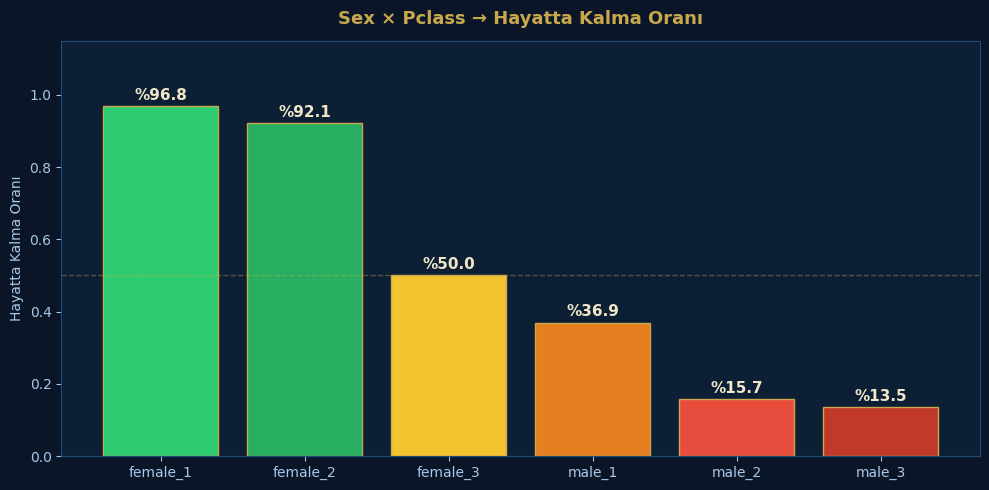

✅ Sex_Pclass sütunu eklendi.
📐 Güncel boyut: 891 satır × 15 sütun


In [47]:
# ============================================================
# ⚡ ADIM 10 — ETKİLEŞİM ÖZELLİĞİ: Sex × Pclass
# ============================================================

# Sex ve Pclass'ı birleştirerek yeni bir kategorik özellik oluştur
df['Sex_Pclass'] = df['Sex'].astype(str) + '_' + df['Pclass'].astype(str)

print("📊 Sex_Pclass kombinasyonları ve hayatta kalma oranları:")
print()
interaction_survived = df.groupby('Sex_Pclass')['Survived'].agg(['mean', 'count']).round(3)
interaction_survived.columns = ['Hayatta Kalma Oranı', 'Kişi Sayısı']
interaction_survived = interaction_survived.sort_values('Hayatta Kalma Oranı', ascending=False)
print(interaction_survived.to_string())
print()

# Sonucu görselleştir
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0a1628')
ax.set_facecolor('#0d1f35')

renkler_map = {
    'female_1': '#2ecc71', 'female_2': '#27ae60', 'female_3': '#f4c430',
    'male_1':   '#e67e22', 'male_2':   '#e74c3c', 'male_3':   '#c0392b'
}
gruplar = interaction_survived.index.tolist()
oranlar = interaction_survived['Hayatta Kalma Oranı'].tolist()
renkler = [renkler_map.get(g, '#a8c8e8') for g in gruplar]

barlar = ax.bar(gruplar, oranlar, color=renkler, edgecolor='#c9a84c', linewidth=1)

for bar, oran in zip(barlar, oranlar):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'%{oran*100:.1f}', ha='center', va='bottom',
            color='#f0e6c8', fontsize=11, fontweight='bold')

ax.set_title('Sex × Pclass → Hayatta Kalma Oranı', color='#c9a84c', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Hayatta Kalma Oranı', color='#a8c8e8')
ax.set_ylim(0, 1.15)
ax.tick_params(colors='#a8c8e8')
ax.axhline(y=0.5, color='#c9a84c', linestyle='--', alpha=0.4, linewidth=1)
for spine in ax.spines.values():
    spine.set_edgecolor('#1e4d7b')

plt.tight_layout()
plt.show()

print(f"✅ Sex_Pclass sütunu eklendi.")
print(f"📐 Güncel boyut: {df.shape[0]} satır × {df.shape[1]} sütun")

# ============================================================
# 🎓 DERS NOTU:
# astype(str) → sayısal Pclass'ı metne çeviriyoruz
# "+" ile string birleştirme → "female" + "_" + "1" = "female_1"
# Bu yöntem basit ama etkili — daha sonra encoding ile sayıya çevireceğiz
# ============================================================


<div style="background: linear-gradient(90deg, #0a1628, #1a3a5c); padding: 18px 25px; border-radius: 12px; border-left: 6px solid #c9a84c; margin: 10px 0;">
  <h2 style="color: #c9a84c; margin: 0; font-size: 1.5em;">📦 Adım 11 — Aykırı Değer (Outlier) Tespiti & Log Dönüşümü</h2>
  <p style="color: #d0e4f7; margin: 8px 0 0 0; font-size: 0.95em;"><code style="background:#1e4d7b; padding:2px 6px; border-radius:4px;">Fare</code> sütununda bazı yolcular 500+ ödedi. Bu aşırı değerler modeli yanıltır — tespit edip yumuşatalım.</p>
</div>

<div style="background: #0d1f35; border-radius: 10px; padding: 22px 25px; border: 1px solid #1e4d7b; color: #d0e4f7; margin-top: 10px;">

  <h3 style="color: #a8c8e8; margin-top: 0;">🔍 IQR Yöntemi ile Tespit</h3>

  <p style="color: #d0e4f7; margin-bottom: 14px;">Aykırı değer tespitinin en yaygın yolu <strong style="color:#f0e6c8;">IQR (Çeyrekler Arası Aralık)</strong> yöntemidir:</p>

  <table style="width:100%; border-collapse: collapse; font-size: 0.95em; margin-bottom: 16px;">
    <tr style="background: rgba(201,168,76,0.15);">
      <th style="color: #c9a84c; padding: 8px 12px; text-align: left; border-bottom: 1px solid #1e4d7b;">Adım</th>
      <th style="color: #c9a84c; padding: 8px 12px; text-align: left; border-bottom: 1px solid #1e4d7b;">Formül</th>
    </tr>
    <tr>
      <td style="padding: 8px 12px; color: #f0e6c8;">IQR hesapla</td>
      <td style="padding: 8px 12px; color: #d0e4f7; font-family: monospace;">IQR = Q3 − Q1</td>
    </tr>
    <tr style="background: rgba(255,255,255,0.03);">
      <td style="padding: 8px 12px; color: #f0e6c8;">Alt sınır</td>
      <td style="padding: 8px 12px; color: #d0e4f7; font-family: monospace;">Q1 − 1.5 × IQR</td>
    </tr>
    <tr>
      <td style="padding: 8px 12px; color: #f0e6c8;">Üst sınır</td>
      <td style="padding: 8px 12px; color: #d0e4f7; font-family: monospace;">Q3 + 1.5 × IQR</td>
    </tr>
    <tr style="background: rgba(255,255,255,0.03);">
      <td style="padding: 8px 12px; color: #f0e6c8;">Aykırı değer</td>
      <td style="padding: 8px 12px; color: #e74c3c;">Bu sınırların dışında kalan her değer</td>
    </tr>
  </table>

  <table style="width:100%; border-collapse: separate; border-spacing: 8px; margin-bottom: 14px;">
    <tr>
      <td style="background: rgba(231,76,60,0.1); border: 1px solid #e74c3c; border-radius: 8px; padding: 14px; width:50%; vertical-align:top;">
        <p style="margin: 0; color: #e74c3c; font-weight: bold;">❌ Silme (Drop)</p>
        <p style="margin: 6px 0 0 0; color: #d0e4f7; font-size: 0.9em;">Aykırı satırları sil → Veri kaybı olur. Titanic gibi küçük veri setlerinde uygun değil.</p>
      </td>
      <td style="background: rgba(46,204,113,0.1); border: 1px solid #2ecc71; border-radius: 8px; padding: 14px; width:50%; vertical-align:top;">
        <p style="margin: 0; color: #2ecc71; font-weight: bold;">✅ Log Dönüşümü</p>
        <p style="margin: 6px 0 0 0; color: #d0e4f7; font-size: 0.9em;">Değerleri silmeden dağılımı normalleştirir. 512 → log(512+1) ≈ 6.2 olur.</p>
      </td>
    </tr>
  </table>

  <div style="background: rgba(201,168,76,0.1); border: 1px solid #c9a84c; border-radius: 8px; padding: 12px 16px;">
    <p style="margin: 0; color: #c9a84c; font-weight: bold;">💡 Neden +1 ekliyoruz?</p>
    <p style="margin: 5px 0 0 0; color: #d0e4f7;">log(0) tanımlı değil. Fare=0 olan yolcular için hata almamak adına <strong style="color:#f0e6c8;">log1p</strong> kullanıyoruz: <code style="background:#1e4d7b; padding:2px 5px; border-radius:4px;">log(x+1)</code></p>
  </div>

</div>


📊 Fare sütunu istatistikleri:
count   891.00
mean     32.20
std      49.69
min       0.00
25%       7.91
50%      14.45
75%      31.00
max     512.33

   Q1 (25. yüzdelik) : 7.91
   Q3 (75. yüzdelik) : 31.00
   IQR               : 23.09
   Alt sınır         : -26.72
   Üst sınır         : 65.63

⚠️  Aykırı değer sayısı (IQR): 116
   Max Fare: 512.33  ← 500+ ödeyen yolcular var!



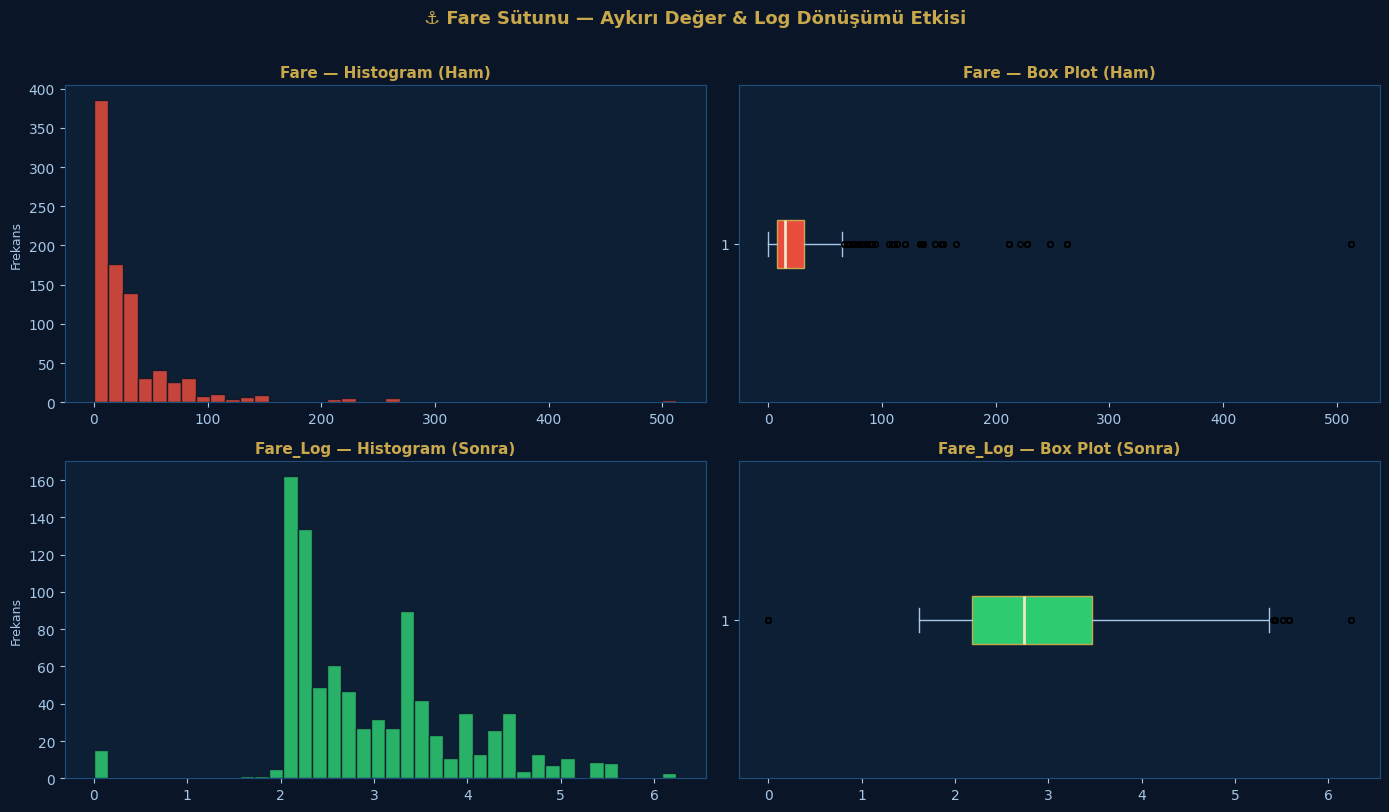

✅ Fare_Log sütunu oluşturuldu (np.log1p kullanıldı).
   → Dağılım çok daha simetrik hale geldi!


In [48]:
# ============================================================
# 📦 ADIM 11 — AYKIRI DEĞER TESPİTİ & LOG DÖNÜŞÜMÜ (FARE)
# ============================================================

print("📊 Fare sütunu istatistikleri:")
print(df['Fare'].describe().round(2).to_string())
print()

# --- IQR Yöntemi ile aykırı değeri tespit et ---
Q1  = df['Fare'].quantile(0.25)
Q3  = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR

print(f"   Q1 (25. yüzdelik) : {Q1:.2f}")
print(f"   Q3 (75. yüzdelik) : {Q3:.2f}")
print(f"   IQR               : {IQR:.2f}")
print(f"   Alt sınır         : {alt_sinir:.2f}")
print(f"   Üst sınır         : {ust_sinir:.2f}")
print()

aykiri_sayisi = ((df['Fare'] < alt_sinir) | (df['Fare'] > ust_sinir)).sum()
print(f"⚠️  Aykırı değer sayısı (IQR): {aykiri_sayisi}")
print(f"   Max Fare: {df['Fare'].max():.2f}  ← 500+ ödeyen yolcular var!")
print()

# --- Görselleştirme: Öncesi ve Sonrası ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.patch.set_facecolor('#0a1628')

basliklar = ['Fare — Histogram (Ham)', 'Fare — Box Plot (Ham)',
             'Fare_Log — Histogram (Sonra)', 'Fare_Log — Box Plot (Sonra)']

# Log dönüşümü uygula
df['Fare_Log'] = np.log1p(df['Fare'])

veri = [df['Fare'], df['Fare'], df['Fare_Log'], df['Fare_Log']]

for idx, (ax, baslik, vr) in enumerate(zip(axes.flatten(), basliklar, veri)):
    ax.set_facecolor('#0d1f35')
    renk = '#e74c3c' if idx < 2 else '#2ecc71'
    if idx in [0, 2]:   # Histogram
        ax.hist(vr.dropna(), bins=40, color=renk, edgecolor='#0a1628', alpha=0.85)
        ax.set_ylabel('Frekans', color='#a8c8e8', fontsize=9)
    else:               # Box plot
        bp = ax.boxplot(vr.dropna(), vert=False, patch_artist=True,
                        boxprops=dict(facecolor=renk, color='#c9a84c'),
                        medianprops=dict(color='#f0e6c8', linewidth=2),
                        whiskerprops=dict(color='#a8c8e8'),
                        capprops=dict(color='#a8c8e8'),
                        flierprops=dict(marker='o', color='#c9a84c', markersize=4))
    ax.set_title(baslik, color='#c9a84c', fontsize=11, fontweight='bold')
    ax.tick_params(colors='#a8c8e8')
    for spine in ax.spines.values():
        spine.set_edgecolor('#1e4d7b')

plt.suptitle('⚓ Fare Sütunu — Aykırı Değer & Log Dönüşümü Etkisi',
             color='#c9a84c', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("✅ Fare_Log sütunu oluşturuldu (np.log1p kullanıldı).")
print("   → Dağılım çok daha simetrik hale geldi!")

# ============================================================
# 🎓 DERS NOTU:
# np.log1p(x) = log(x+1)  → x=0 için güvenli
# Log dönüşümü sağa çarpık (right-skewed) dağılımları normalleştirir
# Linear model, KNN, SVM gibi algoritmalar için dağılım önemlidir
# ============================================================


<div style="background: linear-gradient(90deg, #0a1628, #1a3a5c); padding: 18px 25px; border-radius: 12px; border-left: 6px solid #c9a84c; margin: 10px 0;">
  <h2 style="color: #c9a84c; margin: 0; font-size: 1.5em;">🔢 Adım 12 — Encoding: Kategorik → Sayısal</h2>
  <p style="color: #d0e4f7; margin: 8px 0 0 0; font-size: 0.95em;">Makine öğrenmesi algoritmaları yalnızca <strong style="color:#f0e6c8;">sayı</strong> anlar. <strong style="color:#f0e6c8;">"male"</strong>, <strong style="color:#f0e6c8;">"female"</strong>, <strong style="color:#f0e6c8;">"S"</strong>, <strong style="color:#f0e6c8;">"C"</strong> gibi metin değerlerini modele veremeyiz — önce sayıya dönüştürmeliyiz. Ama <em>nasıl</em> dönüştürdüğümüz son derece önemlidir.</p>
</div>

<div style="background: #0d1f35; border-radius: 10px; padding: 22px 25px; border: 1px solid #1e4d7b; color: #d0e4f7; margin-top: 10px;">

  <h3 style="color: #a8c8e8; margin-top: 0;">🤔 Neden Encoding Gereklidir?</h3>

  <div style="background: rgba(201,168,76,0.08); border: 1px solid #c9a84c; border-radius: 8px; padding: 14px 18px; margin-bottom: 18px;">
    <p style="margin: 0; color: #f0e6c8; font-weight: bold;">🎯 Basit Analoji:</p>
    <p style="margin: 8px 0 0 0; color: #d0e4f7;">Bir hesap makinesine <em>"elma + armut = ?"</em> diyemezsiniz. Makine yalnızca <code style="background:#1a3a5c; color:#c9a84c; padding:2px 5px; border-radius:3px;">3 + 5 = 8</code> gibi işlemler yapar. Makine öğrenmesi modeli de aynı şekilde çalışır — <strong style="color:#f0e6c8;">"male"</strong> yazısını göremez, ama <strong style="color:#f0e6c8;">0</strong> veya <strong style="color:#f0e6c8;">1</strong> sayısını anlayabilir.</p>
  </div>

  <p style="color: #d0e4f7; margin-bottom: 16px; line-height: 1.7;">Veri setimizde şu kategorik sütunlar kaldı:</p>

  <table style="width:100%; border-collapse: collapse; font-size: 0.9em; margin-bottom: 20px;">
    <tr style="background: rgba(201,168,76,0.15);">
      <th style="color: #c9a84c; padding: 8px 10px; text-align: left; border-bottom: 1px solid #1e4d7b;">Sütun</th>
      <th style="color: #c9a84c; padding: 8px 10px; text-align: left; border-bottom: 1px solid #1e4d7b;">Örnek Değerler</th>
      <th style="color: #c9a84c; padding: 8px 10px; text-align: left; border-bottom: 1px solid #1e4d7b;">Özellik</th>
      <th style="color: #c9a84c; padding: 8px 10px; text-align: left; border-bottom: 1px solid #1e4d7b;">Uygulanacak Yöntem</th>
    </tr>
    <tr>
      <td style="padding: 8px 10px; color: #f0e6c8; font-weight: bold;">Sex</td>
      <td style="padding: 8px 10px; color: #d0e4f7;">male, female</td>
      <td style="padding: 8px 10px; color: #d0e4f7;">2 değer, sırasız</td>
      <td style="padding: 8px 10px; color: #2ecc71;">Label Encoding (0/1)</td>
    </tr>
    <tr style="background: rgba(255,255,255,0.03);">
      <td style="padding: 8px 10px; color: #f0e6c8; font-weight: bold;">Embarked</td>
      <td style="padding: 8px 10px; color: #d0e4f7;">S, C, Q</td>
      <td style="padding: 8px 10px; color: #d0e4f7;">3 değer, sırasız</td>
      <td style="padding: 8px 10px; color: #2ecc71;">One-Hot Encoding</td>
    </tr>
    <tr>
      <td style="padding: 8px 10px; color: #f0e6c8; font-weight: bold;">Title</td>
      <td style="padding: 8px 10px; color: #d0e4f7;">Mr, Miss, Mrs, Master, Rare</td>
      <td style="padding: 8px 10px; color: #d0e4f7;">5 değer, sırasız</td>
      <td style="padding: 8px 10px; color: #2ecc71;">Label Encoding (tree model için)</td>
    </tr>
    <tr style="background: rgba(255,255,255,0.03);">
      <td style="padding: 8px 10px; color: #f0e6c8; font-weight: bold;">Sex_Pclass</td>
      <td style="padding: 8px 10px; color: #d0e4f7;">female_1, male_3, ...</td>
      <td style="padding: 8px 10px; color: #d0e4f7;">6 değer, sırasız</td>
      <td style="padding: 8px 10px; color: #2ecc71;">Label Encoding (tree model için)</td>
    </tr>
    <tr>
      <td style="padding: 8px 10px; color: #f0e6c8; font-weight: bold;">AgeGroup, FareGroup</td>
      <td style="padding: 8px 10px; color: #d0e4f7;">Çocuk, Genç, Yetişkin...</td>
      <td style="padding: 8px 10px; color: #d0e4f7;">Sıralı kategorik</td>
      <td style="padding: 8px 10px; color: #2ecc71;">Label Encoding (sıra korunur)</td>
    </tr>
  </table>

  <hr style="border-color: #1e4d7b; margin: 20px 0;">

  <h3 style="color: #a8c8e8;">1️⃣ Label Encoding — İkili (Binary) Değişkenler</h3>

  <p style="color: #d0e4f7; line-height: 1.7; margin-bottom: 12px;">Yalnızca <strong style="color:#f0e6c8;">2 değer</strong> alan sütunlar için idealdir. Bir sütunu <code style="background:#1a3a5c; color:#c9a84c; padding:2px 5px; border-radius:3px;">0</code> ve <code style="background:#1a3a5c; color:#c9a84c; padding:2px 5px; border-radius:3px;">1</code> ile temsil ederiz. Bu dönüşüm model için <strong style="color:#f0e6c8;">yanlış bir sıra bilgisi taşımaz</strong> çünkü iki değer arasında zaten doğal bir ikili ayrım vardır.</p>

  <table style="border-collapse: separate; border-spacing: 12px; width: 100%;">
    <tr>
      <td style="vertical-align: top; background: rgba(231,76,60,0.08); border: 1px solid #e74c3c; border-radius: 8px; padding: 12px 16px; width: 48%;">
        <p style="color: #e74c3c; font-weight: bold; margin: 0 0 8px 0;">❌ Önce (model okuyamaz)</p>
        <table style="border-collapse: collapse; font-size: 0.88em; width: 100%;">
          <tr style="background: rgba(201,168,76,0.1);">
            <th style="color: #c9a84c; padding: 5px 8px; text-align: left; border-bottom: 1px solid #1e4d7b;">PassengerId</th>
            <th style="color: #c9a84c; padding: 5px 8px; text-align: left; border-bottom: 1px solid #1e4d7b;">Sex</th>
          </tr>
          <tr><td style="padding: 5px 8px; color: #d0e4f7;">1</td><td style="padding: 5px 8px; color: #d0e4f7;">male</td></tr>
          <tr style="background:rgba(255,255,255,0.03)"><td style="padding: 5px 8px; color: #d0e4f7;">2</td><td style="padding: 5px 8px; color: #d0e4f7;">female</td></tr>
          <tr><td style="padding: 5px 8px; color: #d0e4f7;">3</td><td style="padding: 5px 8px; color: #d0e4f7;">female</td></tr>
          <tr style="background:rgba(255,255,255,0.03)"><td style="padding: 5px 8px; color: #d0e4f7;">4</td><td style="padding: 5px 8px; color: #d0e4f7;">male</td></tr>
        </table>
      </td>
      <td style="vertical-align: top; background: rgba(46,204,113,0.06); border: 1px solid #2ecc71; border-radius: 8px; padding: 12px 16px; width: 48%;">
        <p style="color: #2ecc71; font-weight: bold; margin: 0 0 8px 0;">✅ Sonra (model anlayabilir)</p>
        <table style="border-collapse: collapse; font-size: 0.88em; width: 100%;">
          <tr style="background: rgba(201,168,76,0.1);">
            <th style="color: #c9a84c; padding: 5px 8px; text-align: left; border-bottom: 1px solid #1e4d7b;">PassengerId</th>
            <th style="color: #c9a84c; padding: 5px 8px; text-align: left; border-bottom: 1px solid #1e4d7b;">Sex</th>
          </tr>
          <tr><td style="padding: 5px 8px; color: #d0e4f7;">1</td><td style="padding: 5px 8px; color: #f0e6c8; font-weight:bold;">1</td></tr>
          <tr style="background:rgba(255,255,255,0.03)"><td style="padding: 5px 8px; color: #d0e4f7;">2</td><td style="padding: 5px 8px; color: #f0e6c8; font-weight:bold;">0</td></tr>
          <tr><td style="padding: 5px 8px; color: #d0e4f7;">3</td><td style="padding: 5px 8px; color: #f0e6c8; font-weight:bold;">0</td></tr>
          <tr style="background:rgba(255,255,255,0.03)"><td style="padding: 5px 8px; color: #d0e4f7;">4</td><td style="padding: 5px 8px; color: #f0e6c8; font-weight:bold;">1</td></tr>
        </table>
      </td>
    </tr>
  </table>

  <hr style="border-color: #1e4d7b; margin: 20px 0;">

  <h3 style="color: #a8c8e8;">2️⃣ One-Hot Encoding — Nominal (Sırasız) Kategorikler</h3>

  <p style="color: #d0e4f7; line-height: 1.7; margin-bottom: 8px;"><strong style="color:#f0e6c8;">3 veya daha fazla değer</strong> alan ve aralarında <strong style="color:#f0e6c8;">sıra/hiyerarşi olmayan</strong> sütunlar için kullanılır. Her benzersiz kategori için <strong style="color:#f0e6c8;">ayrı bir sütun</strong> oluşturulur; yolcunun o kategoriye ait olup olmadığı 0/1 ile gösterilir.</p>

  <p style="color: #d0e4f7; line-height: 1.7; margin-bottom: 12px;">🚢 <code style="background:#1a3a5c; color:#c9a84c; padding:2px 5px; border-radius:3px;">Embarked</code>: Southampton (S), Cherbourg (C), Queenstown (Q) — Bu limanlar arasında herhangi bir büyük/küçük ilişkisi yoktur.</p>

  <table style="border-collapse: separate; border-spacing: 12px; width: 100%;">
    <tr>
      <td style="vertical-align: top; background: rgba(231,76,60,0.08); border: 1px solid #e74c3c; border-radius: 8px; padding: 12px 16px;">
        <p style="color: #e74c3c; font-weight: bold; margin: 0 0 8px 0;">❌ Önce</p>
        <table style="border-collapse: collapse; font-size: 0.88em; width: 100%;">
          <tr style="background: rgba(201,168,76,0.1);">
            <th style="color: #c9a84c; padding: 5px 8px; text-align: left; border-bottom: 1px solid #1e4d7b;">Embarked</th>
          </tr>
          <tr><td style="padding: 5px 8px; color: #d0e4f7;">S</td></tr>
          <tr style="background:rgba(255,255,255,0.03)"><td style="padding: 5px 8px; color: #d0e4f7;">C</td></tr>
          <tr><td style="padding: 5px 8px; color: #d0e4f7;">Q</td></tr>
          <tr style="background:rgba(255,255,255,0.03)"><td style="padding: 5px 8px; color: #d0e4f7;">S</td></tr>
        </table>
      </td>
      <td style="vertical-align: top; background: rgba(46,204,113,0.06); border: 1px solid #2ecc71; border-radius: 8px; padding: 12px 16px;">
        <p style="color: #2ecc71; font-weight: bold; margin: 0 0 8px 0;">✅ Sonra (drop_first=True ile 2 sütun)</p>
        <table style="border-collapse: collapse; font-size: 0.88em; width: 100%;">
          <tr style="background: rgba(201,168,76,0.1);">
            <th style="color: #c9a84c; padding: 5px 8px; text-align: left; border-bottom: 1px solid #1e4d7b;">Embarked_Q</th>
            <th style="color: #c9a84c; padding: 5px 8px; text-align: left; border-bottom: 1px solid #1e4d7b;">Embarked_S</th>
          </tr>
          <tr><td style="padding: 5px 8px; color: #f0e6c8;">0</td><td style="padding: 5px 8px; color: #f0e6c8;">1</td></tr>
          <tr style="background:rgba(255,255,255,0.03)"><td style="padding: 5px 8px; color: #f0e6c8;">0</td><td style="padding: 5px 8px; color: #f0e6c8;">0</td></tr>
          <tr><td style="padding: 5px 8px; color: #f0e6c8;">1</td><td style="padding: 5px 8px; color: #f0e6c8;">0</td></tr>
          <tr style="background:rgba(255,255,255,0.03)"><td style="padding: 5px 8px; color: #f0e6c8;">0</td><td style="padding: 5px 8px; color: #f0e6c8;">1</td></tr>
        </table>
        <p style="color: #a8c8e8; font-size:0.82em; margin: 8px 0 0 0;">💡 İkisi de 0 ise → Cherbourg (C) demektir. 3. sütuna gerek yok!</p>
      </td>
    </tr>
  </table>

  <hr style="border-color: #1e4d7b; margin: 20px 0;">

  <h3 style="color: #a8c8e8;">3️⃣ Neden Yanlış Encoding Tehlikelidir?</h3>

  <div style="background: rgba(231,76,60,0.08); border: 1px solid #e74c3c; border-radius: 8px; padding: 14px 18px; margin-bottom: 16px;">
    <p style="margin: 0 0 8px 0; color: #e74c3c; font-weight: bold;">⚠️ Senaryo: Embarked'a Label Encoding uygulasaydık ne olurdu?</p>
    <table style="border-collapse: collapse; font-size: 0.9em; width: auto; margin: 8px 0;">
      <tr style="background: rgba(201,168,76,0.1);">
        <th style="color: #c9a84c; padding: 6px 12px; border-bottom: 1px solid #1e4d7b;">Kategori</th>
        <th style="color: #c9a84c; padding: 6px 12px; border-bottom: 1px solid #1e4d7b;">Verilen Sayı</th>
        <th style="color: #c9a84c; padding: 6px 12px; border-bottom: 1px solid #1e4d7b;">Modelin Yorumu (Yanlış!)</th>
      </tr>
      <tr><td style="padding: 6px 12px; color: #d0e4f7;">Southampton (S)</td><td style="padding: 6px 12px; color: #f0e6c8;">0</td><td style="padding: 6px 12px; color: #e74c3c;">En küçük → En az önemli?</td></tr>
      <tr style="background:rgba(255,255,255,0.03)"><td style="padding: 6px 12px; color: #d0e4f7;">Queenstown (Q)</td><td style="padding: 6px 12px; color: #f0e6c8;">1</td><td style="padding: 6px 12px; color: #e74c3c;">S'den 1 büyük → S'ye yakın?</td></tr>
      <tr><td style="padding: 6px 12px; color: #d0e4f7;">Cherbourg (C)</td><td style="padding: 6px 12px; color: #f0e6c8;">2</td><td style="padding: 6px 12px; color: #e74c3c;">En büyük → En önemli?</td></tr>
    </table>
    <p style="margin: 10px 0 0 0; color: #d0e4f7; line-height: 1.6;">Model bu sayılar arasında <strong style="color:#e74c3c;">matematiksel bir ilişki</strong> olduğunu varsayar: <em>(S + C) / 2 = Q</em> gibi saçma bir sonuç çıkarır. Oysa limanlar arasında böyle bir ilişki <strong style="color:#e74c3c;">hiç yoktur</strong>.</p>
  </div>

  <h3 style="color: #a8c8e8;">4️⃣ drop_first=True Neden Kullanıyoruz?</h3>

  <div style="background: rgba(201,168,76,0.08); border: 1px solid #c9a84c; border-radius: 8px; padding: 14px 18px;">
    <p style="margin: 0 0 10px 0; color: #c9a84c; font-weight: bold;">💡 Dummy Variable Trap (Kukla Değişken Tuzağı)</p>
    <p style="margin: 0 0 8px 0; color: #d0e4f7; line-height: 1.6;">3 kategoriden <strong style="color:#f0e6c8;">3 sütun</strong> oluşturursak, bu 3 sütun birbirinden <strong style="color:#f0e6c8;">tamamen türetilebilir</strong> — yani biri fazladır. Örneğin:</p>
    <p style="margin: 8px 0; color: #a8c8e8; font-style: italic; padding-left: 16px;">Embarked_C = 0, Embarked_Q = 0 &nbsp;→&nbsp; Embarked_S = 1 olduğu kesin.</p>
    <p style="margin: 8px 0 0 0; color: #d0e4f7; line-height: 1.6;">Bu duruma <strong style="color:#c9a84c;">multicollinearity</strong> (çoklu doğrusallık) denir ve model eğitimini bozar. <code style="background:#1a3a5c; color:#c9a84c; padding:2px 5px; border-radius:3px;">drop_first=True</code> ile ilk kategoriyi düşürürüz — 2 sütun yeterlidir.</p>
  </div>

  <h3 style="color: #a8c8e8; margin-top: 20px;">⚖️ Yöntem Özet Tablosu</h3>
  <table style="width:100%; border-collapse: collapse; font-size: 0.9em;">
    <tr style="background: rgba(201,168,76,0.15);">
      <th style="color: #c9a84c; padding: 8px 10px; text-align: left; border-bottom: 1px solid #1e4d7b;">Yöntem</th>
      <th style="color: #c9a84c; padding: 8px 10px; text-align: left; border-bottom: 1px solid #1e4d7b;">Ne Zaman?</th>
      <th style="color: #c9a84c; padding: 8px 10px; text-align: left; border-bottom: 1px solid #1e4d7b;">Bu Projede</th>
    </tr>
    <tr>
      <td style="padding: 8px 10px; color: #f0e6c8; font-weight: bold;">Label Encoding</td>
      <td style="padding: 8px 10px; color: #d0e4f7;">2 değerli (binary) veya tree-based model</td>
      <td style="padding: 8px 10px; color: #2ecc71;">Sex, Title, Sex_Pclass, AgeGroup, FareGroup</td>
    </tr>
    <tr style="background: rgba(255,255,255,0.03);">
      <td style="padding: 8px 10px; color: #f0e6c8; font-weight: bold;">One-Hot Encoding</td>
      <td style="padding: 8px 10px; color: #d0e4f7;">Sırasız nominal, lineer/uzaklık tabanlı model</td>
      <td style="padding: 8px 10px; color: #2ecc71;">Embarked → Embarked_Q, Embarked_S</td>
    </tr>
    <tr>
      <td style="padding: 8px 10px; color: #f0e6c8; font-weight: bold;">Ordinal Encoding</td>
      <td style="padding: 8px 10px; color: #d0e4f7;">Sıralı kategorik (küçük/orta/büyük vb.)</td>
      <td style="padding: 8px 10px; color: #2ecc71;">Pclass zaten sayı ✅ — ek işlem gerekmez</td>
    </tr>
  </table>

</div>


In [49]:
# ============================================================
# 🔢 ADIM 12 — ENCODİNG: KATEGORİK → SAYISAL
# ============================================================

print("📋 Encoding öncesi kategorik sütunlar:")
kategorik = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(kategorik)
print()

# --- 1. Label Encoding: Sex (binary) ---
df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})
print("✅ Sex → male=1, female=0 (Label Encoding)")

# --- 2. One-Hot Encoding: Embarked (nominal, 3 değer) ---
df = pd.get_dummies(df, columns=['Embarked'], prefix='Embarked', drop_first=True, dtype=int)
print("✅ Embarked → One-Hot (Embarked_Q, Embarked_S) oluşturuldu")
print("   (Embarked_C referans olarak düşürüldü — drop_first=True)")

# --- 3. Label Encoding: Title (tree modeller için yeterli) ---
le = LabelEncoder()
df['Title'] = le.fit_transform(df['Title'])
print(f"✅ Title → Label Encoding uygulandı: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# --- 4. Label Encoding: Sex_Pclass ---
df['Sex_Pclass'] = le.fit_transform(df['Sex_Pclass'])
print(f"✅ Sex_Pclass → Label Encoding uygulandı")

# --- 5. AgeGroup ve FareGroup: Ordinal Encoding ---
age_sirasi   = ['Çocuk', 'Genç', 'Yetişkin', 'Orta Yaş', 'Yaşlı']
fare_sirasi  = ['Düşük', 'Orta-Alt', 'Orta', 'Orta-Üst', 'Yüksek']

df['AgeGroup']  = df['AgeGroup'].astype(str)
df['FareGroup'] = df['FareGroup'].astype(str)

age_map  = {v: i for i, v in enumerate(age_sirasi)}
fare_map = {v: i for i, v in enumerate(fare_sirasi)}

df['AgeGroup']  = df['AgeGroup'].map(age_map)
df['FareGroup'] = df['FareGroup'].map(fare_map)
print("✅ AgeGroup  → Ordinal Encoding (Çocuk=0 ... Yaşlı=4)")
print("✅ FareGroup → Ordinal Encoding (Düşük=0 ... Yüksek=4)")

print()
print("📋 Encoding sonrası sütun tipleri:")
print(df.dtypes.to_string())
print()
print(f"📐 Güncel boyut: {df.shape[0]} satır × {df.shape[1]} sütun")

# ============================================================
# 🎓 DERS NOTU:
# pd.get_dummies()  → One-Hot Encoding (pandas built-in)
# LabelEncoder()    → sklearn sınıfı, kategorilere 0,1,2... atar
# .map({})          → Python dict ile manuel etiket atama
# drop_first=True   → n-1 sütun yeterli (multicollinearity önlemi)
# ============================================================


📋 Encoding öncesi kategorik sütunlar:
['Sex', 'Embarked', 'Title', 'AgeGroup', 'FareGroup', 'Sex_Pclass']

✅ Sex → male=1, female=0 (Label Encoding)
✅ Embarked → One-Hot (Embarked_Q, Embarked_S) oluşturuldu
   (Embarked_C referans olarak düşürüldü — drop_first=True)
✅ Title → Label Encoding uygulandı: {'Master': np.int64(0), 'Miss': np.int64(1), 'Mr': np.int64(2), 'Mrs': np.int64(3), 'Rare': np.int64(4)}
✅ Sex_Pclass → Label Encoding uygulandı
✅ AgeGroup  → Ordinal Encoding (Çocuk=0 ... Yaşlı=4)
✅ FareGroup → Ordinal Encoding (Düşük=0 ... Yüksek=4)

📋 Encoding sonrası sütun tipleri:
Survived        int64
Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Title           int64
Has_Cabin       int64
FamilySize      int64
IsAlone         int64
AgeGroup        int64
FareGroup     float64
Sex_Pclass      int64
Fare_Log      float64
Embarked_Q      int64
Embarked_S      int64

📐 Güncel boyut: 891 satır × 17 sütu

<div style="background: linear-gradient(90deg, #0a1628, #1a3a5c); padding: 18px 25px; border-radius: 12px; border-left: 6px solid #c9a84c; margin: 10px 0;">
  <h2 style="color: #c9a84c; margin: 0; font-size: 1.5em;">✂️ Adım 13 — Train/Test Split & Data Leakage</h2>
  <p style="color: #d0e4f7; margin: 8px 0 0 0; font-size: 0.95em;">Model değerlendirmesinin altın kuralı: <strong style="color:#f0e6c8;">test verisi hiçbir zaman eğitime katılmamalı.</strong> Bu kuralı çiğnemek Data Leakage'a yol açar — model gerçekte başarısız olsa bile başarılı <em>görünür</em>.</p>
</div>

<div style="background: #0d1f35; border-radius: 10px; padding: 22px 25px; border: 1px solid #1e4d7b; color: #d0e4f7; margin-top: 10px;">

  <h3 style="color: #a8c8e8; margin-top: 0;">📚 Train/Test Split Nedir ve Neden Gereklidir?</h3>

  <div style="background: rgba(201,168,76,0.08); border: 1px solid #c9a84c; border-radius: 8px; padding: 14px 18px; margin-bottom: 18px;">
    <p style="margin: 0 0 8px 0; color: #f0e6c8; font-weight: bold;">🎯 Sınav Analojisi:</p>
    <p style="margin: 0; color: #d0e4f7; line-height: 1.7;">Bir öğrenciyi değerlendirirken sınav sorularını önceden göstermek ne kadar adil olur? Hiç. Öğrenci soruları ezberler ama gerçekte hiçbir şey öğrenmemiştir. <strong style="color:#f0e6c8;">Makine öğrenmesi modeli de aynı şekilde:</strong> eğer test verisiyle karşılaşmışsa, o verideki sonuçları "ezberler" ve gerçek hayatta işe yaramaz.</p>
    <p style="margin: 10px 0 0 0; color: #d0e4f7; line-height: 1.7;">Bu yüzden veriyi ikiye böleriz: modelin <strong style="color:#c9a84c;">öğrendiği (train)</strong> ve <strong style="color:#c9a84c;">sınavda sorulacak (test)</strong> kısım. Test verisi model tarafından hiç görülmez — sadece değerlendirme aşamasında kullanılır.</p>
  </div>

  <table style="width:100%; border-collapse: collapse; font-size: 0.9em; margin-bottom: 20px;">
    <tr style="background: rgba(201,168,76,0.15);">
      <th style="color: #c9a84c; padding: 8px 12px; text-align: left; border-bottom: 1px solid #1e4d7b;">Küme</th>
      <th style="color: #c9a84c; padding: 8px 12px; text-align: left; border-bottom: 1px solid #1e4d7b;">Oran</th>
      <th style="color: #c9a84c; padding: 8px 12px; text-align: left; border-bottom: 1px solid #1e4d7b;">Kullanım Amacı</th>
      <th style="color: #c9a84c; padding: 8px 12px; text-align: left; border-bottom: 1px solid #1e4d7b;">Titan Üzerinde</th>
    </tr>
    <tr>
      <td style="padding: 8px 12px; color: #f0e6c8; font-weight: bold;">Train (Eğitim)</td>
      <td style="padding: 8px 12px; color: #d0e4f7;">%80</td>
      <td style="padding: 8px 12px; color: #d0e4f7;">Modelin parametrelerini öğreneceği veri</td>
      <td style="padding: 8px 12px; color: #d0e4f7;">~712 yolcu</td>
    </tr>
    <tr style="background: rgba(255,255,255,0.03);">
      <td style="padding: 8px 12px; color: #f0e6c8; font-weight: bold;">Test (Sınav)</td>
      <td style="padding: 8px 12px; color: #d0e4f7;">%20</td>
      <td style="padding: 8px 12px; color: #d0e4f7;">Modelin hiç görmediği, nihai değerlendirme verisi</td>
      <td style="padding: 8px 12px; color: #d0e4f7;">~179 yolcu</td>
    </tr>
  </table>

  <hr style="border-color: #1e4d7b; margin: 20px 0;">

  <h3 style="color: #a8c8e8;">🚰 Data Leakage (Veri Sızıntısı) Nedir?</h3>

  <div style="background: rgba(231,76,60,0.08); border: 1px solid #e74c3c; border-radius: 8px; padding: 14px 18px; margin-bottom: 16px;">
    <p style="margin: 0 0 8px 0; color: #e74c3c; font-weight: bold;">⚠️ Gerçek Hayat Analojisi:</p>
    <p style="margin: 0 0 8px 0; color: #d0e4f7; line-height: 1.7;">Bir borsacı sabah gelen haberlerden yarın hisse fiyatlarını tahmin etmeye çalışıyor. Ama sisteme <em>"gelecekteki"</em> fiyat verisini de yanlışlıkla eklemişse — model %99 doğruluk gösterir! Gerçek hayatta ise hiç işe yaramaz çünkü o gelecek veri yoktur.</p>
    <p style="margin: 0; color: #d0e4f7; line-height: 1.7;"><strong style="color:#e74c3c;">Data Leakage:</strong> test setindeki bilginin, farkında olmadan eğitim aşamasına sızmasıdır. En yaygın örneği <strong style="color:#f0e6c8;">tüm veriye önce scaler uygulamak, sonra bölmektir.</strong></p>
  </div>

  <h3 style="color: #a8c8e8; margin-top: 20px;">🔍 Leakage Nasıl Oluşur? — Adım Adım</h3>

  <p style="color: #d0e4f7; margin-bottom: 14px; line-height: 1.7;"><code style="background:#1a3a5c; color:#c9a84c; padding:2px 6px; border-radius:3px;">StandardScaler</code>, verideki <strong style="color:#f0e6c8;">ortalama (mean)</strong> ve <strong style="color:#f0e6c8;">standart sapma (std)</strong> değerlerini öğrenir. Eğer bu istatistikleri tüm veri üzerinde hesaplarsak, test setinin bilgisi de bu istatistiğe dahil olur:</p>

  <table style="border-collapse: separate; border-spacing: 10px; width: 100%; margin-bottom: 20px;">
    <tr>
      <td style="vertical-align: top; background: rgba(231,76,60,0.08); border: 1px solid #e74c3c; border-radius: 8px; padding: 14px 18px; width: 48%;">
        <p style="color: #e74c3c; font-weight: bold; margin: 0 0 10px 0;">❌ YANLIŞ Sıralama (Leakage!)</p>
        <div style="background: rgba(0,0,0,0.2); border-radius: 6px; padding: 10px 14px; font-family: monospace; font-size: 0.85em; color: #d0e4f7; line-height: 1.8;">
          <span style="color:#e74c3c;">1.</span> scaler.fit_transform(<span style="color:#f0e6c8;">tüm_df</span>)  <span style="color:#808080;"># ← Leakage!</span><br>
          <span style="color:#e74c3c;">2.</span> X_train, X_test = split(...)
        </div>
        <p style="margin: 10px 0 0 0; color: #e74c3c; font-size: 0.88em; line-height: 1.6;">Scaler, test setinin ortalama ve std'sini <strong>gördü</strong>. Test verisi artık "saf" değil — sınav sorularını önceden görmüş gibi!</p>
      </td>
      <td style="vertical-align: top; background: rgba(46,204,113,0.06); border: 1px solid #2ecc71; border-radius: 8px; padding: 14px 18px; width: 48%;">
        <p style="color: #2ecc71; font-weight: bold; margin: 0 0 10px 0;">✅ DOĞRU Sıralama</p>
        <div style="background: rgba(0,0,0,0.2); border-radius: 6px; padding: 10px 14px; font-family: monospace; font-size: 0.85em; color: #d0e4f7; line-height: 1.8;">
          <span style="color:#2ecc71;">1.</span> X_train, X_test = split(...)<br>
          <span style="color:#2ecc71;">2.</span> scaler.fit(<span style="color:#f0e6c8;">X_train</span>)  <span style="color:#808080;"># sadece train</span><br>
          <span style="color:#2ecc71;">3.</span> scaler.transform(<span style="color:#f0e6c8;">X_train</span>)<br>
          <span style="color:#2ecc71;">4.</span> scaler.transform(<span style="color:#f0e6c8;">X_test</span>)   <span style="color:#808080;"># sadece dönüştür</span>
        </div>
        <p style="margin: 10px 0 0 0; color: #2ecc71; font-size: 0.88em; line-height: 1.6;">Scaler yalnızca train verisi üzerinden istatistik öğrenir. Test verisi hiçbir bilgiyi sızdırmaz — <strong>gerçek performans ölçülür</strong>.</p>
      </td>
    </tr>
  </table>

  <div style="background: rgba(201,168,76,0.08); border: 1px solid #c9a84c; border-radius: 8px; padding: 14px 18px; margin-bottom: 20px;">
    <p style="margin: 0 0 8px 0; color: #c9a84c; font-weight: bold;">💡 fit() ile transform() Farkı Nedir?</p>
    <table style="width:100%; border-collapse: collapse; font-size: 0.9em;">
      <tr style="background: rgba(201,168,76,0.1);">
        <th style="color: #c9a84c; padding: 6px 10px; border-bottom: 1px solid #1e4d7b;">Metod</th>
        <th style="color: #c9a84c; padding: 6px 10px; border-bottom: 1px solid #1e4d7b;">Ne Yapar?</th>
        <th style="color: #c9a84c; padding: 6px 10px; border-bottom: 1px solid #1e4d7b;">Kime Uygulanır?</th>
      </tr>
      <tr>
        <td style="padding: 6px 10px; color: #f0e6c8; font-family:monospace;">fit()</td>
        <td style="padding: 6px 10px; color: #d0e4f7;">Veriyi <strong style="color:#f0e6c8;">"öğrenir"</strong> — mean, std gibi istatistikleri hesaplar ve kaydeder</td>
        <td style="padding: 6px 10px; color: #2ecc71;">Yalnızca <strong>X_train</strong></td>
      </tr>
      <tr style="background: rgba(255,255,255,0.03);">
        <td style="padding: 6px 10px; color: #f0e6c8; font-family:monospace;">transform()</td>
        <td style="padding: 6px 10px; color: #d0e4f7;">Öğrenilen istatistikleri kullanarak veriyi <strong style="color:#f0e6c8;">dönüştürür</strong></td>
        <td style="padding: 6px 10px; color: #2ecc71;">Hem <strong>X_train</strong> hem <strong>X_test</strong></td>
      </tr>
      <tr>
        <td style="padding: 6px 10px; color: #f0e6c8; font-family:monospace;">fit_transform()</td>
        <td style="padding: 6px 10px; color: #d0e4f7;">fit() + transform() birleşimi — kısayol</td>
        <td style="padding: 6px 10px; color: #2ecc71;">Yalnızca <strong>X_train</strong> <span style="color:#e74c3c;">(X_test'e uygulanmaz!)</span></td>
      </tr>
    </table>
  </div>

  <hr style="border-color: #1e4d7b; margin: 20px 0;">

  <h3 style="color: #a8c8e8;">⚙️ train_test_split Parametreleri</h3>

  <table style="width:100%; border-collapse: collapse; font-size: 0.9em; margin-bottom: 16px;">
    <tr style="background: rgba(201,168,76,0.15);">
      <th style="color: #c9a84c; padding: 8px 12px; text-align: left; border-bottom: 1px solid #1e4d7b;">Parametre</th>
      <th style="color: #c9a84c; padding: 8px 12px; text-align: left; border-bottom: 1px solid #1e4d7b;">Değer</th>
      <th style="color: #c9a84c; padding: 8px 12px; text-align: left; border-bottom: 1px solid #1e4d7b;">Ne İşe Yarar?</th>
    </tr>
    <tr>
      <td style="padding: 8px 12px; color: #f0e6c8; font-family:monospace;">test_size=0.2</td>
      <td style="padding: 8px 12px; color: #d0e4f7;">%20</td>
      <td style="padding: 8px 12px; color: #d0e4f7;">Verinin %20'si test, %80'i train olarak ayrılır. Küçük veri setlerinde %30 da kullanılabilir.</td>
    </tr>
    <tr style="background: rgba(255,255,255,0.03);">
      <td style="padding: 8px 12px; color: #f0e6c8; font-family:monospace;">random_state=42</td>
      <td style="padding: 8px 12px; color: #d0e4f7;">42 (sabit)</td>
      <td style="padding: 8px 12px; color: #d0e4f7;">Rastgele bölme işlemi her çalıştırmada aynı sonucu verir — sonuçlar <strong style="color:#f0e6c8;">tekrarlanabilir</strong> olur. 42 sayısının özel bir anlamı yoktur, gelenek haline gelmiştir.</td>
    </tr>
    <tr>
      <td style="padding: 8px 12px; color: #f0e6c8; font-family:monospace;">stratify=y</td>
      <td style="padding: 8px 12px; color: #d0e4f7;">Hedef değişken</td>
      <td style="padding: 8px 12px; color: #d0e4f7;">Train ve test setlerindeki <strong style="color:#f0e6c8;">sınıf oranlarının korunmasını</strong> sağlar. Aşağıya bakınız ↓</td>
    </tr>
  </table>

  <div style="background: rgba(231,76,60,0.08); border: 1px solid #e74c3c; border-radius: 8px; padding: 14px 18px; margin-bottom: 12px;">
    <p style="margin: 0 0 8px 0; color: #e74c3c; font-weight: bold;">⚠️ stratify Kullanmazsak Ne Olur?</p>
    <p style="margin: 0 0 8px 0; color: #d0e4f7; line-height: 1.6;">Titanic: %62 hayatta kalmadı, %38 hayatta kaldı. Bölme rastgele yapılırsa test setine yanlışlıkla çok fazla hayatta kalanlar düşebilir:</p>
    <table style="border-collapse: collapse; font-size: 0.88em; width: auto;">
      <tr style="background: rgba(201,168,76,0.1);">
        <th style="color: #c9a84c; padding: 5px 12px; border-bottom: 1px solid #1e4d7b;">Set</th>
        <th style="color: #c9a84c; padding: 5px 12px; border-bottom: 1px solid #1e4d7b;">stratify olmadan (kötü şans)</th>
        <th style="color: #c9a84c; padding: 5px 12px; border-bottom: 1px solid #1e4d7b;">stratify=y (garantili)</th>
      </tr>
      <tr>
        <td style="padding: 5px 12px; color: #d0e4f7;">Train</td>
        <td style="padding: 5px 12px; color: #e74c3c;">%50 hayatta / %50 hayatta değil</td>
        <td style="padding: 5px 12px; color: #2ecc71;">%38 hayatta / %62 hayatta değil ✅</td>
      </tr>
      <tr style="background:rgba(255,255,255,0.03)">
        <td style="padding: 5px 12px; color: #d0e4f7;">Test</td>
        <td style="padding: 5px 12px; color: #e74c3c;">%26 hayatta / %74 hayatta değil</td>
        <td style="padding: 5px 12px; color: #2ecc71;">%38 hayatta / %62 hayatta değil ✅</td>
      </tr>
    </table>
    <p style="margin: 10px 0 0 0; color: #d0e4f7; line-height: 1.6; font-size: 0.9em;">Sınıf oranı korunmazsa model yanlı bir veriyle eğitilir ve test sonuçları gerçeği yansıtmaz.</p>
  </div>

</div>


In [50]:
# ============================================================
# ✂️ ADIM 13 — TRAIN/TEST SPLIT & DATA LEAKAGE DERSİ
# ============================================================

# Hedef değişken ve özellikler
y = df['Survived']
X = df.drop(columns=['Survived'])

print(f"📐 Toplam veri: {X.shape[0]} satır × {X.shape[1]} özellik")
print(f"📋 Özellikler: {list(X.columns)}")
print()

# --- YANLIŞ YAKLAŞIM (gösterim amaçlı — YAPMAYIN!) ---
print("❌ YANLIŞ: Önce tüm veriye Scaler uygulansaydı:")
from sklearn.preprocessing import StandardScaler as _SS
_sc = _SS()
_hatali = _sc.fit_transform(X.select_dtypes(include='number'))
print("   → Scaler test verisini de 'gördü' — DATA LEAKAGE!")
print()

# --- DOĞRU YAKLAŞIM ---
print("✅ DOĞRU: Önce böl, sonra fit_transform sadece train'e!")
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # Sınıf dengesini koru
)

print(f"   X_train : {X_train.shape[0]} satır (%{X_train.shape[0]/len(X)*100:.1f})")
print(f"   X_test  : {X_test.shape[0]} satır (%{X_test.shape[0]/len(X)*100:.1f})")
print()

# Stratify kontrolü
print("📊 Orijinal Survived dağılımı:")
print(f"   0: %{(y==0).mean()*100:.1f}   1: %{(y==1).mean()*100:.1f}")
print("📊 Train Survived dağılımı:")
print(f"   0: %{(y_train==0).mean()*100:.1f}   1: %{(y_train==1).mean()*100:.1f}")
print("📊 Test Survived dağılımı:")
print(f"   0: %{(y_test==0).mean()*100:.1f}   1: %{(y_test==1).mean()*100:.1f}")
print()
print("✅ stratify=y sayesinde oranlar korundu!")

# ============================================================
# 🎓 DERS NOTU:
# stratify=y → her iki sette de Survived oranı aynı kalır
#              sınıf dengesizliği olan veri setlerinde ÇOK önemli
# random_state=42 → rastgeleliği sabitler, tekrar çalıştırınca aynı bölünme
# ============================================================


📐 Toplam veri: 891 satır × 16 özellik
📋 Özellikler: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Title', 'Has_Cabin', 'FamilySize', 'IsAlone', 'AgeGroup', 'FareGroup', 'Sex_Pclass', 'Fare_Log', 'Embarked_Q', 'Embarked_S']

❌ YANLIŞ: Önce tüm veriye Scaler uygulansaydı:
   → Scaler test verisini de 'gördü' — DATA LEAKAGE!

✅ DOĞRU: Önce böl, sonra fit_transform sadece train'e!
   X_train : 712 satır (%79.9)
   X_test  : 179 satır (%20.1)

📊 Orijinal Survived dağılımı:
   0: %61.6   1: %38.4
📊 Train Survived dağılımı:
   0: %61.7   1: %38.3
📊 Test Survived dağılımı:
   0: %61.5   1: %38.5

✅ stratify=y sayesinde oranlar korundu!


<div style="background: linear-gradient(90deg, #0a1628, #1a3a5c); padding: 18px 25px; border-radius: 12px; border-left: 6px solid #c9a84c; margin: 10px 0;">
  <h2 style="color: #c9a84c; margin: 0; font-size: 1.5em;">⚖️ Adım 14 — Ölçeklendirme (Scaling): 3 Yöntem</h2>
  <p style="color: #d0e4f7; margin: 8px 0 0 0; font-size: 0.95em;">Age=30, Fare=500, FamilySize=5 — hepsi farklı ölçekte. Scaling uygulamazsak model yüksek sayılı sütunu <em>daha önemli</em> zanneder. Scaling bunu düzeltir.</p>
</div>

<div style="background: #0d1f35; border-radius: 10px; padding: 22px 25px; border: 1px solid #1e4d7b; color: #d0e4f7; margin-top: 10px;">

  <h3 style="color: #a8c8e8; margin-top: 0;">🤔 Scaling Neden Gereklidir?</h3>

  <div style="background: rgba(201,168,76,0.08); border: 1px solid #c9a84c; border-radius: 8px; padding: 14px 18px; margin-bottom: 18px;">
    <p style="margin: 0 0 8px 0; color: #f0e6c8; font-weight: bold;">🎯 Balıkçı Terazisi Analojisi:</p>
    <p style="margin: 0 0 8px 0; color: #d0e4f7; line-height: 1.7;">Bir kişinin ağırlığını ölçmek için <strong style="color:#f0e6c8;">gram cinsinden (75.000)</strong> mi yoksa <strong style="color:#f0e6c8;">kilogram cinsinden (75)</strong> mi kullanırsanız fark eder mi? Fiziksel olarak hayır, ama bir makine öğrenmesi modeli için <strong style="color:#e74c3c;">gram cinsinden olan değer 1000 kat daha "baskın" gelir!</strong></p>
    <p style="margin: 0; color: #d0e4f7; line-height: 1.7;">Model mesafelere veya büyüklüklere bakarak öğrenir. Büyük sayılar, küçük sayıları gölgeler — tek sütunun baskısı altında kalır.</p>
  </div>

  <div style="background: rgba(231,76,60,0.08); border: 1px solid #e74c3c; border-radius: 8px; padding: 14px 18px; margin-bottom: 18px;">
    <p style="margin: 0 0 10px 0; color: #e74c3c; font-weight: bold;">⚠️ Titanic Verisi Scaling Olmadan: Sorun</p>
    <table style="border-collapse: collapse; font-size: 0.88em; width: 100%;">
      <tr style="background: rgba(201,168,76,0.1);">
        <th style="color: #c9a84c; padding: 6px 10px; border-bottom: 1px solid #1e4d7b;">Sütun</th>
        <th style="color: #c9a84c; padding: 6px 10px; border-bottom: 1px solid #1e4d7b;">Min</th>
        <th style="color: #c9a84c; padding: 6px 10px; border-bottom: 1px solid #1e4d7b;">Max</th>
        <th style="color: #c9a84c; padding: 6px 10px; border-bottom: 1px solid #1e4d7b;">Model Etkisi</th>
      </tr>
      <tr>
        <td style="padding: 6px 10px; color: #f0e6c8;">Fare</td>
        <td style="padding: 6px 10px; color: #d0e4f7;">0</td>
        <td style="padding: 6px 10px; color: #e74c3c; font-weight:bold;">512</td>
        <td style="padding: 6px 10px; color: #e74c3c;">Modeli domine eder 😱</td>
      </tr>
      <tr style="background:rgba(255,255,255,0.03)">
        <td style="padding: 6px 10px; color: #f0e6c8;">Age</td>
        <td style="padding: 6px 10px; color: #d0e4f7;">0.4</td>
        <td style="padding: 6px 10px; color: #d0e4f7;">80</td>
        <td style="padding: 6px 10px; color: #d0e4f7;">Orta etki</td>
      </tr>
      <tr>
        <td style="padding: 6px 10px; color: #f0e6c8;">FamilySize</td>
        <td style="padding: 6px 10px; color: #d0e4f7;">1</td>
        <td style="padding: 6px 10px; color: #d0e4f7;">11</td>
        <td style="padding: 6px 10px; color: #d0e4f7;">Zayıf etki</td>
      </tr>
      <tr style="background:rgba(255,255,255,0.03)">
        <td style="padding: 6px 10px; color: #f0e6c8;">IsAlone</td>
        <td style="padding: 6px 10px; color: #d0e4f7;">0</td>
        <td style="padding: 6px 10px; color: #d0e4f7;">1</td>
        <td style="padding: 6px 10px; color: #e74c3c;">Neredeyse göz ardı edilir 😞</td>
      </tr>
    </table>
    <p style="margin: 10px 0 0 0; color: #d0e4f7; font-size: 0.9em; line-height: 1.6;">Scaling ile hepsini aynı aralığa getiririz → model her sütuna <strong style="color:#f0e6c8;">eşit şans</strong> tanır.</p>
  </div>

  <p style="color: #a8c8e8; font-size: 0.88em; margin-bottom: 20px;">⚠️ <strong style="color:#f0e6c8;">Önemli Not:</strong> Scaling yalnızca <strong>mesafe tabanlı</strong> modellerde (KNN, SVM, Lojistik Regresyon, Yapay Sinir Ağları) etkilidir. Karar Ağacı ve Random Forest gibi <strong>ağaç tabanlı</strong> modeller scaling'e ihtiyaç duymaz — ama uygulamak da zarar vermez.</p>

  <hr style="border-color: #1e4d7b; margin: 20px 0;">

  <h3 style="color: #a8c8e8;">1️⃣ StandardScaler — Z-Score Normalizasyonu</h3>

  <p style="color: #d0e4f7; line-height: 1.7; margin-bottom: 10px;">Her değerden ortalamayı çıkar, standart sapmaya böl. Sonuç: <strong style="color:#f0e6c8;">ortalama = 0, standart sapma = 1.</strong></p>

  <div style="background: rgba(0,0,0,0.2); border-radius: 8px; padding: 12px 18px; margin-bottom: 12px; font-family: monospace; font-size: 0.95em; text-align: center;">
    <span style="color: #c9a84c; font-size: 1.1em;">z = (x − μ) / σ</span>
    <span style="color: #a8c8e8; font-size: 0.85em; margin-left: 16px;">μ: ortalama &nbsp;|&nbsp; σ: standart sapma</span>
  </div>

  <p style="color: #d0e4f7; line-height: 1.7; margin-bottom: 10px;"><strong style="color:#f0e6c8;">Somut Örnek:</strong> Age sütunu: ortalama = 30, std = 14</p>
  <table style="border-collapse: collapse; font-size: 0.88em; width: auto; margin-bottom: 12px;">
    <tr style="background: rgba(201,168,76,0.1);">
      <th style="color: #c9a84c; padding: 6px 14px; border-bottom: 1px solid #1e4d7b;">Orijinal Yaş</th>
      <th style="color: #c9a84c; padding: 6px 14px; border-bottom: 1px solid #1e4d7b;">İşlem</th>
      <th style="color: #c9a84c; padding: 6px 14px; border-bottom: 1px solid #1e4d7b;">Scaled</th>
      <th style="color: #c9a84c; padding: 6px 14px; border-bottom: 1px solid #1e4d7b;">Yorum</th>
    </tr>
    <tr><td style="padding: 6px 14px; color: #d0e4f7;">16</td><td style="padding: 6px 14px; color: #a8c8e8;">(16−30)/14</td><td style="padding: 6px 14px; color: #f0e6c8;">−1.0</td><td style="padding: 6px 14px; color: #d0e4f7;">Ortalamadan 1 std altında</td></tr>
    <tr style="background:rgba(255,255,255,0.03)"><td style="padding: 6px 14px; color: #d0e4f7;">30</td><td style="padding: 6px 14px; color: #a8c8e8;">(30−30)/14</td><td style="padding: 6px 14px; color: #f0e6c8;">0.0</td><td style="padding: 6px 14px; color: #d0e4f7;">Tam ortalama</td></tr>
    <tr><td style="padding: 6px 14px; color: #d0e4f7;">44</td><td style="padding: 6px 14px; color: #a8c8e8;">(44−30)/14</td><td style="padding: 6px 14px; color: #f0e6c8;">+1.0</td><td style="padding: 6px 14px; color: #d0e4f7;">Ortalamadan 1 std üstünde</td></tr>
    <tr style="background:rgba(255,255,255,0.03)"><td style="padding: 6px 14px; color: #d0e4f7;">72</td><td style="padding: 6px 14px; color: #a8c8e8;">(72−30)/14</td><td style="padding: 6px 14px; color: #f0e6c8;">+3.0</td><td style="padding: 6px 14px; color: #d0e4f7;">Potansiyel aykırı değer</td></tr>
  </table>
  <div style="background: rgba(231,76,60,0.06); border: 1px solid #e74c3c; border-radius: 6px; padding: 10px 14px; margin-bottom: 16px;">
    <p style="margin: 0; color: #e74c3c; font-size: 0.88em; line-height: 1.6;">⚠️ <strong>Zayıf Yanı:</strong> Aykırı değerlere duyarlıdır. Titanic'te Fare=512 gibi uç değerler istatistikleri bozar → Bunun yerine <strong>RobustScaler</strong> tercih edilir.</p>
  </div>

  <hr style="border-color: #1e4d7b; margin: 20px 0;">

  <h3 style="color: #a8c8e8;">2️⃣ MinMaxScaler — 0-1 Arası Sıkıştırma</h3>

  <p style="color: #d0e4f7; line-height: 1.7; margin-bottom: 10px;">En küçük değer 0, en büyük değer 1 olacak şekilde tüm değerleri <strong style="color:#f0e6c8;">[0, 1] aralığına sıkıştırır.</strong></p>

  <div style="background: rgba(0,0,0,0.2); border-radius: 8px; padding: 12px 18px; margin-bottom: 12px; font-family: monospace; font-size: 0.95em; text-align: center;">
    <span style="color: #c9a84c; font-size: 1.1em;">x_scaled = (x − x_min) / (x_max − x_min)</span>
  </div>

  <p style="color: #d0e4f7; line-height: 1.7; margin-bottom: 10px;"><strong style="color:#f0e6c8;">Somut Örnek:</strong> FamilySize sütunu: min=1, max=11</p>
  <table style="border-collapse: collapse; font-size: 0.88em; width: auto; margin-bottom: 12px;">
    <tr style="background: rgba(201,168,76,0.1);">
      <th style="color: #c9a84c; padding: 6px 14px; border-bottom: 1px solid #1e4d7b;">Orijinal FamilySize</th>
      <th style="color: #c9a84c; padding: 6px 14px; border-bottom: 1px solid #1e4d7b;">İşlem</th>
      <th style="color: #c9a84c; padding: 6px 14px; border-bottom: 1px solid #1e4d7b;">Scaled</th>
    </tr>
    <tr><td style="padding: 6px 14px; color: #d0e4f7;">1 (tek başına)</td><td style="padding: 6px 14px; color: #a8c8e8;">(1−1)/(11−1)</td><td style="padding: 6px 14px; color: #f0e6c8;">0.0</td></tr>
    <tr style="background:rgba(255,255,255,0.03)"><td style="padding: 6px 14px; color: #d0e4f7;">6</td><td style="padding: 6px 14px; color: #a8c8e8;">(6−1)/(11−1)</td><td style="padding: 6px 14px; color: #f0e6c8;">0.5</td></tr>
    <tr><td style="padding: 6px 14px; color: #d0e4f7;">11 (büyük aile)</td><td style="padding: 6px 14px; color: #a8c8e8;">(11−1)/(11−1)</td><td style="padding: 6px 14px; color: #f0e6c8;">1.0</td></tr>
  </table>
  <div style="background: rgba(231,76,60,0.06); border: 1px solid #e74c3c; border-radius: 6px; padding: 10px 14px; margin-bottom: 16px;">
    <p style="margin: 0; color: #e74c3c; font-size: 0.88em; line-height: 1.6;">⚠️ <strong>Zayıf Yanı:</strong> Aykırı değerlere en duyarlı yöntemdir. Fare=512 gibi tek bir uç değer tüm diğer değerleri 0'a yakın sıkıştırır.</p>
  </div>

  <hr style="border-color: #1e4d7b; margin: 20px 0;">

  <h3 style="color: #a8c8e8;">3️⃣ RobustScaler — Aykırı Değere Dayanıklı ✅ Titanic İçin Tercih</h3>

  <p style="color: #d0e4f7; line-height: 1.7; margin-bottom: 10px;">Ortalama ve std yerine <strong style="color:#f0e6c8;">medyan ve IQR</strong> kullanır. Aykırı değerler medyanı ve IQR'ı fazla etkilemez, bu yüzden robustur.</p>

  <div style="background: rgba(0,0,0,0.2); border-radius: 8px; padding: 12px 18px; margin-bottom: 12px; font-family: monospace; font-size: 0.95em; text-align: center;">
    <span style="color: #c9a84c; font-size: 1.1em;">x_scaled = (x − medyan) / IQR</span>
    <span style="color: #a8c8e8; font-size: 0.85em; margin-left: 16px;">IQR = Q3 − Q1 (ortadaki %50'lik dilim)</span>
  </div>

  <div style="background: rgba(201,168,76,0.08); border: 1px solid #c9a84c; border-radius: 8px; padding: 14px 18px; margin-bottom: 16px;">
    <p style="margin: 0 0 8px 0; color: #c9a84c; font-weight: bold;">💡 Neden Medyan ve IQR Daha Sağlam?</p>
    <p style="margin: 0 0 8px 0; color: #d0e4f7; line-height: 1.7;">10 yolcunun Fare değerleri: <code style="background:#1a3a5c; color:#f0e6c8; padding:2px 6px; border-radius:3px;">7, 8, 9, 10, 10, 11, 12, 13, 14, 512</code></p>
    <table style="border-collapse: collapse; font-size: 0.88em; width: auto;">
      <tr style="background: rgba(201,168,76,0.1);">
        <th style="color: #c9a84c; padding: 5px 12px; border-bottom: 1px solid #1e4d7b;">İstatistik</th>
        <th style="color: #c9a84c; padding: 5px 12px; border-bottom: 1px solid #1e4d7b;">512 olmadan</th>
        <th style="color: #c9a84c; padding: 5px 12px; border-bottom: 1px solid #1e4d7b;">512 varken</th>
        <th style="color: #c9a84c; padding: 5px 12px; border-bottom: 1px solid #1e4d7b;">Değişim</th>
      </tr>
      <tr>
        <td style="padding: 5px 12px; color: #f0e6c8;">Ortalama (mean)</td>
        <td style="padding: 5px 12px; color: #d0e4f7;">10.4</td>
        <td style="padding: 5px 12px; color: #e74c3c;">60.6</td>
        <td style="padding: 5px 12px; color: #e74c3c;">6x arttı 😱</td>
      </tr>
      <tr style="background:rgba(255,255,255,0.03)">
        <td style="padding: 5px 12px; color: #f0e6c8;">Medyan</td>
        <td style="padding: 5px 12px; color: #d0e4f7;">10.5</td>
        <td style="padding: 5px 12px; color: #2ecc71;">10.5</td>
        <td style="padding: 5px 12px; color: #2ecc71;">Değişmedi ✅</td>
      </tr>
    </table>
    <p style="margin: 10px 0 0 0; color: #d0e4f7; font-size: 0.9em; line-height: 1.6;">Medyan uç değerden etkilenmez çünkü sıralı dizinin ortasındaki değere bakar. Bu yüzden RobustScaler'ın kullandığı medyan, Fare gibi çarpık dağılımlı verilerde훨씬 daha güvenilirdir.</p>
  </div>

  <hr style="border-color: #1e4d7b; margin: 20px 0;">

  <h3 style="color: #a8c8e8;">⚖️ 3 Yöntem Karşılaştırma Tablosu</h3>

  <table style="width:100%; border-collapse: collapse; font-size: 0.9em; margin-bottom: 20px;">
    <tr style="background: rgba(201,168,76,0.15);">
      <th style="color: #c9a84c; padding: 8px 10px; text-align: left; border-bottom: 1px solid #1e4d7b;">Yöntem</th>
      <th style="color: #c9a84c; padding: 8px 10px; text-align: left; border-bottom: 1px solid #1e4d7b;">Formül</th>
      <th style="color: #c9a84c; padding: 8px 10px; text-align: left; border-bottom: 1px solid #1e4d7b;">Sonuç Aralığı</th>
      <th style="color: #c9a84c; padding: 8px 10px; text-align: left; border-bottom: 1px solid #1e4d7b;">Aykırı Değere</th>
      <th style="color: #c9a84c; padding: 8px 10px; text-align: left; border-bottom: 1px solid #1e4d7b;">Ne Zaman?</th>
    </tr>
    <tr>
      <td style="padding: 8px 10px; color: #f0e6c8; font-weight: bold;">StandardScaler</td>
      <td style="padding: 8px 10px; color: #d0e4f7; font-family:monospace;">(x−μ)/σ</td>
      <td style="padding: 8px 10px; color: #d0e4f7;">~−3 ile +3</td>
      <td style="padding: 8px 10px; color: #e74c3c;">Duyarlı</td>
      <td style="padding: 8px 10px; color: #d0e4f7;">Normal dağılım, SVM, Loj. Reg.</td>
    </tr>
    <tr style="background: rgba(255,255,255,0.03);">
      <td style="padding: 8px 10px; color: #f0e6c8; font-weight: bold;">MinMaxScaler</td>
      <td style="padding: 8px 10px; color: #d0e4f7; font-family:monospace;">(x−min)/(max−min)</td>
      <td style="padding: 8px 10px; color: #d0e4f7;">[0, 1]</td>
      <td style="padding: 8px 10px; color: #e74c3c;">Çok duyarlı</td>
      <td style="padding: 8px 10px; color: #d0e4f7;">Sinir ağları, görüntü işleme</td>
    </tr>
    <tr>
      <td style="padding: 8px 10px; color: #f0e6c8; font-weight: bold;">RobustScaler</td>
      <td style="padding: 8px 10px; color: #d0e4f7; font-family:monospace;">(x−medyan)/IQR</td>
      <td style="padding: 8px 10px; color: #d0e4f7;">Esnek</td>
      <td style="padding: 8px 10px; color: #2ecc71; font-weight:bold;">Dayanıklı ✅</td>
      <td style="padding: 8px 10px; color: #2ecc71; font-weight:bold;">Aykırı değer varsa — Titanic!</td>
    </tr>
  </table>

  <div style="background: rgba(201,168,76,0.1); border: 1px solid #c9a84c; border-radius: 8px; padding: 12px 16px;">
    <p style="margin: 0 0 8px 0; color: #c9a84c; font-weight: bold;">💡 Hangi Sütunları Ölçeklendiriyoruz?</p>
    <table style="border-collapse: collapse; font-size: 0.88em; width: 100%;">
      <tr style="background: rgba(201,168,76,0.1);">
        <th style="color: #c9a84c; padding: 5px 10px; border-bottom: 1px solid #1e4d7b;">Sütun</th>
        <th style="color: #c9a84c; padding: 5px 10px; border-bottom: 1px solid #1e4d7b;">Scaling Gerekli mi?</th>
        <th style="color: #c9a84c; padding: 5px 10px; border-bottom: 1px solid #1e4d7b;">Neden?</th>
      </tr>
      <tr><td style="padding: 5px 10px; color: #f0e6c8;">Age, Fare_log, FamilySize</td><td style="padding: 5px 10px; color: #2ecc71;">✅ Evet</td><td style="padding: 5px 10px; color: #d0e4f7;">Sürekli sayısal, farklı ölçekler</td></tr>
      <tr style="background:rgba(255,255,255,0.03)"><td style="padding: 5px 10px; color: #f0e6c8;">IsAlone, Has_Cabin</td><td style="padding: 5px 10px; color: #e74c3c;">❌ Hayır</td><td style="padding: 5px 10px; color: #d0e4f7;">Zaten 0/1 (binary) — aralık sabit</td></tr>
      <tr><td style="padding: 5px 10px; color: #f0e6c8;">Sex, Title (encoded)</td><td style="padding: 5px 10px; color: #e74c3c;">❌ Hayır</td><td style="padding: 5px 10px; color: #d0e4f7;">Kategorik etiket — sayısal büyüklük ifade etmez</td></tr>
      <tr style="background:rgba(255,255,255,0.03)"><td style="padding: 5px 10px; color: #f0e6c8;">Pclass</td><td style="padding: 5px 10px; color: #e74c3c;">❌ Hayır</td><td style="padding: 5px 10px; color: #d0e4f7;">Yalnızca 1/2/3 — aralık çok dar</td></tr>
    </table>
  </div>

</div>


In [51]:
# ============================================================
# ⚖️ ADIM 14 — ÖLÇEKLENDİRME (SCALING): 3 YÖNTEM KARŞILAŞTIRMA
# ============================================================

# Ölçeklendirilecek sürekli sütunlar
olceklenecek = ['Age', 'Fare', 'Fare_Log', 'FamilySize']

# Mevcut değerleri yazdır
print("📊 Ölçeklendirme öncesi istatistikler (train seti):")
print(X_train[olceklenecek].describe().round(2).to_string())
print()

# --- 3 Scaler'ı karşılaştır ---
scalerlar = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler'  : MinMaxScaler(),
    'RobustScaler'  : RobustScaler()
}

karsilastirma = {}
for isim, scaler in scalerlar.items():
    gecici = scaler.fit_transform(X_train[olceklenecek])
    gecici_df = pd.DataFrame(gecici, columns=olceklenecek)
    karsilastirma[isim] = gecici_df['Fare'].describe().round(3)

print("📊 Fare sütunu — 3 Scaler Karşılaştırması:")
karsilastirma_df = pd.DataFrame(karsilastirma)
print(karsilastirma_df.to_string())
print()

# --- Gerçek Uygulama: RobustScaler (Titanic için en uygun) ---
# Fare'de aykırı değer var → RobustScaler tercih edilir
scaler = RobustScaler()

# ÖNEMLİ: sadece train'e fit et!
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[olceklenecek] = scaler.fit_transform(X_train[olceklenecek])   # fit + transform
X_test_scaled[olceklenecek]  = scaler.transform(X_test[olceklenecek])         # sadece transform!

print("✅ RobustScaler uygulandı:")
print(f"   fit_transform → X_train ({X_train_scaled.shape[0]} satır)")
print(f"   transform     → X_test  ({X_test_scaled.shape[0]} satır)")
print()
print("📊 Ölçeklendirme sonrası Fare (RobustScaler):")
print(X_train_scaled['Fare'].describe().round(3).to_string())

# ============================================================
# 🎓 DERS NOTU:
# fit_transform = önce istatistikleri öğren (fit), sonra uygula (transform)
# transform     = sadece uygula — test setinde FIT YAPILMAZ!
# Bu kural Data Leakage'ı önlemenin temelidir.
# ============================================================


📊 Ölçeklendirme öncesi istatistikler (train seti):
         Age   Fare  Fare_Log  FamilySize
count 712.00 712.00    712.00      712.00
mean   29.32  31.82      2.95        1.88
std    13.50  48.06      0.98        1.59
min     0.42   0.00      0.00        1.00
25%    21.00   7.90      2.19        1.00
50%    27.00  14.45      2.74        1.00
75%    38.00  31.00      3.47        2.00
max    80.00 512.33      6.24       11.00

📊 Fare sütunu — 3 Scaler Karşılaştırması:
       StandardScaler  MinMaxScaler  RobustScaler
count          712.00        712.00        712.00
mean            -0.00          0.06          0.75
std              1.00          0.09          2.08
min             -0.66          0.00         -0.63
25%             -0.50          0.01         -0.28
50%             -0.36          0.03          0.00
75%             -0.02          0.06          0.72
max             10.01          1.00         21.55

✅ RobustScaler uygulandı:
   fit_transform → X_train (712 satır)
   transform

<div style="background: linear-gradient(90deg, #0a1628, #1a3a5c); padding: 18px 25px; border-radius: 12px; border-left: 6px solid #c9a84c; margin: 10px 0;">
  <h2 style="color: #c9a84c; margin: 0; font-size: 1.5em;">⚗️ Adım 15 — Sınıf Dengesizliğiyle Başa Çıkma: Resampling</h2>
  <p style="color: #d0e4f7; margin: 8px 0 0 0; font-size: 0.95em;">Adım 2'de gördük: %61.6 hayatta kalmadı, %38.4 kurtuldu. Model <em>"herkesi ölmüş tahmin et"</em> derse bile %62 doğruluk alır — ama hiçbir şey öğrenmemiştir. Bu dengesizliği düzeltmek için 3 farklı yöntem vardır.</p>
</div>

<div style="background: #0d1f35; border-radius: 10px; padding: 22px 25px; border: 1px solid #1e4d7b; color: #d0e4f7; margin-top: 10px;">

  <h3 style="color: #a8c8e8; margin-top: 0;">🤔 Sınıf Dengesizliği Neden Sorun Çıkarır?</h3>

  <div style="background: rgba(201,168,76,0.08); border: 1px solid #c9a84c; border-radius: 8px; padding: 14px 18px; margin-bottom: 18px;">
    <p style="margin: 0 0 8px 0; color: #f0e6c8; font-weight: bold;">🎯 Tembel Öğrenci Analojisi:</p>
    <p style="margin: 0 0 8px 0; color: #d0e4f7; line-height: 1.7;">Bir sınıfta 100 sorudan 62'si "Yanlış", 38'i "Doğru" cevaplı. Hiçbir şey öğrenmeden <strong style="color:#f0e6c8;">her şeye "Yanlış" cevabını versen</strong> — %62 doğruluk alırsın! Ama 38 doğru sorunun hepsini kaçırdın.</p>
    <p style="margin: 0; color: #d0e4f7; line-height: 1.7;">Makine öğrenmesi modeli de aynı şekilde davranır: <strong style="color:#e74c3c;">çoğunluk sınıfını her zaman tahmin etmeye</strong> eğilimlidir çünkü bu en az "hata" veren yoldur. Azınlık sınıfı (genellikle "ilginç" olan — hasta tespiti, dolandırıcılık, hayatta kalma) göz ardı edilir.</p>
  </div>

  <div style="background: rgba(231,76,60,0.08); border: 1px solid #e74c3c; border-radius: 8px; padding: 14px 18px; margin-bottom: 20px;">
    <p style="margin: 0 0 10px 0; color: #e74c3c; font-weight: bold;">⚠️ Titanic'te Somut Sonuç:</p>
    <table style="border-collapse: collapse; font-size: 0.9em; width: auto;">
      <tr style="background: rgba(201,168,76,0.1);">
        <th style="color: #c9a84c; padding: 6px 14px; border-bottom: 1px solid #1e4d7b;">Sınıf</th>
        <th style="color: #c9a84c; padding: 6px 14px; border-bottom: 1px solid #1e4d7b;">Gerçek Sayı</th>
        <th style="color: #c9a84c; padding: 6px 14px; border-bottom: 1px solid #1e4d7b;">Oran</th>
        <th style="color: #c9a84c; padding: 6px 14px; border-bottom: 1px solid #1e4d7b;">Dengesiz model tahmini</th>
      </tr>
      <tr>
        <td style="padding: 6px 14px; color: #f0e6c8;">Hayatta Kalmadı (0)</td>
        <td style="padding: 6px 14px; color: #d0e4f7;">549</td>
        <td style="padding: 6px 14px; color: #e74c3c; font-weight:bold;">%61.6</td>
        <td style="padding: 6px 14px; color: #2ecc71;">Doğru tahmin eder ✅</td>
      </tr>
      <tr style="background:rgba(255,255,255,0.03)">
        <td style="padding: 6px 14px; color: #f0e6c8;">Hayatta Kaldı (1)</td>
        <td style="padding: 6px 14px; color: #d0e4f7;">342</td>
        <td style="padding: 6px 14px; color: #e74c3c; font-weight:bold;">%38.4</td>
        <td style="padding: 6px 14px; color: #e74c3c;">Büyük çoğunluğunu kaçırır ❌</td>
      </tr>
    </table>
    <p style="margin: 10px 0 0 0; color: #d0e4f7; font-size: 0.9em; line-height: 1.6;">Model yüksek doğruluk gösterir ama <strong style="color:#e74c3c;">hayatta kalanları tahmin etmede başarısızdır</strong> — bu tıp, finans ve güvenlik gibi kritik alanlarda felaket olabilir.</p>
  </div>

  <hr style="border-color: #1e4d7b; margin: 20px 0;">

  <h3 style="color: #a8c8e8;">1️⃣ SMOTE — Yapay Örnek Üretme (Oversampling)</h3>

  <p style="color: #d0e4f7; line-height: 1.7; margin-bottom: 10px;"><strong style="color:#f0e6c8;">SMOTE</strong> (Synthetic Minority Over-sampling Technique): Az olan sınıfı (hayatta kalanlar) <strong style="color:#f0e6c8;">yapay ama gerçekçi yeni örnekler yaratarak</strong> çoğaltır. Var olan örnekleri kopyalamaz — aralarını doldurur.</p>

  <div style="background: rgba(201,168,76,0.08); border: 1px solid #c9a84c; border-radius: 8px; padding: 14px 18px; margin-bottom: 14px;">
    <p style="margin: 0 0 10px 0; color: #c9a84c; font-weight: bold;">💡 SMOTE Nasıl Çalışır? — Adım Adım</p>
    <ol style="color: #d0e4f7; padding-left: 20px; line-height: 1.9; margin: 0;">
      <li>Az sınıftan bir örnek seç (örneğin: <em>Yaş=25, Fare_log=3.2, FamilySize=2</em> olan hayatta kalan bir yolcu)</li>
      <li>Bu örneğe en yakın <strong style="color:#f0e6c8;">K komşusunu</strong> bul (aynı sınıftan)</li>
      <li>Bu örnek ile komşulardan biri arasında <strong style="color:#f0e6c8;">rastgele bir noktayı</strong> interpolasyonla oluştur</li>
      <li>Oluşturulan yapay nokta, veri setine yeni bir örnek olarak eklenir</li>
    </ol>
  </div>

  <table style="border-collapse: separate; border-spacing: 10px; width: 100%; margin-bottom: 14px;">
    <tr>
      <td style="vertical-align: top; background: rgba(231,76,60,0.08); border: 1px solid #e74c3c; border-radius: 8px; padding: 12px 16px; width: 48%;">
        <p style="color: #e74c3c; font-weight: bold; margin: 0 0 8px 0;">❌ SMOTE Olmadan (Dengesiz)</p>
        <p style="margin: 0; color: #d0e4f7; font-size: 0.9em; line-height: 1.7;">Train: 549 ölü, 342 hayatta<br>Model çoğunluğu taklit eder →<br>Hayatta kalanların büyük çoğunluğu <strong style="color:#e74c3c;">gözden kaçar</strong></p>
      </td>
      <td style="vertical-align: top; background: rgba(46,204,113,0.06); border: 1px solid #2ecc71; border-radius: 8px; padding: 12px 16px; width: 48%;">
        <p style="color: #2ecc71; font-weight: bold; margin: 0 0 8px 0;">✅ SMOTE Sonrası (Dengeli)</p>
        <p style="margin: 0; color: #d0e4f7; font-size: 0.9em; line-height: 1.7;">Train: 549 ölü, <strong style="color:#f0e6c8;">549 hayatta (yapay)</strong><br>Model her iki sınıfı eşit öğrenir →<br>Hayatta kalanlar <strong style="color:#2ecc71;">doğru tahmin edilir</strong></p>
      </td>
    </tr>
  </table>

  <div style="background: rgba(231,76,60,0.06); border: 1px solid #e74c3c; border-radius: 6px; padding: 10px 14px; margin-bottom: 20px;">
    <p style="margin: 0; color: #e74c3c; font-size: 0.88em; line-height: 1.6;">⚠️ <strong>Zayıf Yanı:</strong> Yapay veri üretir — eğitim süresi uzar. Aşırı öğrenme (overfitting) riski artabilir. Sadece <strong>train setine</strong> uygulanmalıdır.</p>
  </div>

  <hr style="border-color: #1e4d7b; margin: 20px 0;">

  <h3 style="color: #a8c8e8;">2️⃣ RandomUnderSampler — Çoğunluğu Azalt</h3>

  <p style="color: #d0e4f7; line-height: 1.7; margin-bottom: 10px;">Yeni örnek üretmek yerine <strong style="color:#f0e6c8;">çoğunluk sınıfından rastgele örnekler siler</strong> — az sınıf kadar veri kalır. Hızlıdır ama veri kaybına yol açar.</p>

  <table style="border-collapse: separate; border-spacing: 10px; width: 100%; margin-bottom: 14px;">
    <tr>
      <td style="vertical-align: top; background: rgba(231,76,60,0.08); border: 1px solid #e74c3c; border-radius: 8px; padding: 12px 16px; width: 48%;">
        <p style="color: #e74c3c; font-weight: bold; margin: 0 0 8px 0;">❌ Önce</p>
        <p style="margin: 0; color: #d0e4f7; font-size: 0.9em; line-height: 1.7;">Train: <strong style="color:#e74c3c;">549</strong> ölü, 342 hayatta<br>Toplam: 891 satır</p>
      </td>
      <td style="vertical-align: top; background: rgba(46,204,113,0.06); border: 1px solid #2ecc71; border-radius: 8px; padding: 12px 16px; width: 48%;">
        <p style="color: #2ecc71; font-weight: bold; margin: 0 0 8px 0;">✅ Sonra</p>
        <p style="margin: 0; color: #d0e4f7; font-size: 0.9em; line-height: 1.7;">Train: <strong style="color:#f0e6c8;">342</strong> ölü, 342 hayatta<br>Toplam: 684 satır <span style="color:#e74c3c;">(207 satır silindi!)</span></p>
      </td>
    </tr>
  </table>

  <div style="background: rgba(231,76,60,0.06); border: 1px solid #e74c3c; border-radius: 6px; padding: 10px 14px; margin-bottom: 20px;">
    <p style="margin: 0; color: #e74c3c; font-size: 0.88em; line-height: 1.6;">⚠️ <strong>Zayıf Yanı:</strong> Silinen örnekler içinde <strong>önemli kalıplar</strong> barındırıyor olabilir. Büyük veri setlerinde daha güvenli, küçük setlerde (Titanic gibi) dikkatli kullanılmalı.</p>
  </div>

  <hr style="border-color: #1e4d7b; margin: 20px 0;">

  <h3 style="color: #a8c8e8;">3️⃣ class_weight='balanced' — En Pratik Yöntem</h3>

  <p style="color: #d0e4f7; line-height: 1.7; margin-bottom: 10px;">Veriyi değiştirmez. Bunun yerine modele <strong style="color:#f0e6c8;">"az sınıftaki hatalar daha ağır" </strong>diyerek eğitir. sklearn'deki çoğu sınıflandırıcıda doğrudan parametre olarak verilir.</p>

  <div style="background: rgba(0,0,0,0.2); border-radius: 8px; padding: 12px 18px; margin-bottom: 12px; font-family: monospace; font-size: 0.9em; color: #d0e4f7; line-height: 1.8;">
    <span style="color: #808080;"># Otomatik: sklearn sınıf oranına göre ağırlıkları hesaplar</span><br>
    <span style="color: #c9a84c;">LogisticRegression</span>(class_weight=<span style="color: #f0e6c8;">'balanced'</span>)<br>
    <br>
    <span style="color: #808080;"># Manuel: kendin belirleyebilirsin</span><br>
    <span style="color: #c9a84c;">LogisticRegression</span>(class_weight=<span style="color: #f0e6c8;">{0: 1, 1: 1.6}</span>)
    <span style="color: #808080;">  # hayatta kalanlar 1.6x daha önemli</span>
  </div>

  <div style="background: rgba(201,168,76,0.08); border: 1px solid #c9a84c; border-radius: 8px; padding: 12px 16px; margin-bottom: 20px;">
    <p style="margin: 0 0 8px 0; color: #c9a84c; font-weight: bold;">💡 Ağırlık Nasıl Hesaplanır?</p>
    <p style="margin: 0 0 6px 0; color: #d0e4f7; line-height: 1.7;"><code style="background:#1a3a5c; color:#f0e6c8; padding:2px 6px; border-radius:3px;">balanced</code> modunda sklearn şu formülü kullanır:</p>
    <div style="background: rgba(0,0,0,0.2); border-radius: 6px; padding: 8px 14px; font-family:monospace; font-size:0.9em; color:#c9a84c; margin-bottom:8px;">
      w_sınıf = toplam_örnek / (sınıf_sayısı × o_sınıftaki_örnek)
    </div>
    <p style="margin: 0; color: #d0e4f7; font-size:0.9em; line-height:1.6;">Titanic için: w₀ = 891 / (2 × 549) ≈ 0.81 &nbsp;|&nbsp; w₁ = 891 / (2 × 342) ≈ 1.30 → Hayatta kalanlar 1.6× daha ağırlıklı</p>
  </div>

  <hr style="border-color: #1e4d7b; margin: 20px 0;">

  <h3 style="color: #a8c8e8;">⚖️ 3 Yöntem Karşılaştırma Tablosu</h3>

  <table style="width:100%; border-collapse: collapse; font-size: 0.9em; margin-bottom: 18px;">
    <tr style="background: rgba(201,168,76,0.15);">
      <th style="color: #c9a84c; padding: 8px 10px; text-align: left; border-bottom: 1px solid #1e4d7b;">Yöntem</th>
      <th style="color: #c9a84c; padding: 8px 10px; text-align: left; border-bottom: 1px solid #1e4d7b;">Veri Büyütür mü?</th>
      <th style="color: #c9a84c; padding: 8px 10px; text-align: left; border-bottom: 1px solid #1e4d7b;">Veri Siler mi?</th>
      <th style="color: #c9a84c; padding: 8px 10px; text-align: left; border-bottom: 1px solid #1e4d7b;">Zorluk</th>
      <th style="color: #c9a84c; padding: 8px 10px; text-align: left; border-bottom: 1px solid #1e4d7b;">En iyi Ne Zaman?</th>
    </tr>
    <tr>
      <td style="padding: 8px 10px; color: #f0e6c8; font-weight:bold;">SMOTE</td>
      <td style="padding: 8px 10px; color: #2ecc71;">✅ Evet (yapay)</td>
      <td style="padding: 8px 10px; color: #2ecc71;">❌ Hayır</td>
      <td style="padding: 8px 10px; color: #d0e4f7;">Orta</td>
      <td style="padding: 8px 10px; color: #d0e4f7;">Yeterli veri var, kayıp istemiyorsan</td>
    </tr>
    <tr style="background: rgba(255,255,255,0.03);">
      <td style="padding: 8px 10px; color: #f0e6c8; font-weight:bold;">UnderSampling</td>
      <td style="padding: 8px 10px; color: #e74c3c;">❌ Hayır</td>
      <td style="padding: 8px 10px; color: #e74c3c;">⚠️ Evet</td>
      <td style="padding: 8px 10px; color: #d0e4f7;">Kolay</td>
      <td style="padding: 8px 10px; color: #d0e4f7;">Çok büyük veri setleri (milyonlarca satır)</td>
    </tr>
    <tr>
      <td style="padding: 8px 10px; color: #f0e6c8; font-weight:bold;">class_weight</td>
      <td style="padding: 8px 10px; color: #2ecc71;">❌ Hayır</td>
      <td style="padding: 8px 10px; color: #2ecc71;">❌ Hayır</td>
      <td style="padding: 8px 10px; color: #2ecc71; font-weight:bold;">En Kolay ⭐</td>
      <td style="padding: 8px 10px; color: #2ecc71; font-weight:bold;">Hızlı başlangıç, az veri</td>
    </tr>
  </table>

  <div style="background: rgba(231,76,60,0.08); border: 1px solid #e74c3c; border-radius: 8px; padding: 14px 18px;">
    <p style="margin: 0 0 6px 0; color: #e74c3c; font-weight: bold;">🚨 Kritik Kural — Resampling Sadece TRAIN Setine Uygulanır!</p>
    <p style="margin: 0; color: #d0e4f7; line-height: 1.7;">Test seti gerçek dünyayı temsil eder — doğal dengesizliği olduğu gibi korunmalıdır. Test setine resampling uygulamak, modelin <strong style="color:#e74c3c;">gerçekte olmayan bir performans</strong> göstermesine yol açar. Tıpkı sınav sorularını önceden vermek gibi.</p>
    <div style="background: rgba(0,0,0,0.2); border-radius: 6px; padding: 10px 14px; margin-top: 10px; font-family:monospace; font-size:0.88em; color:#d0e4f7; line-height:1.8;">
      <span style="color:#2ecc71;">✅ smote.fit_resample(</span><span style="color:#f0e6c8;">X_train</span><span style="color:#2ecc71;">, y_train)</span>  <span style="color:#808080;"># DOĞRU</span><br>
      <span style="color:#e74c3c;">❌ smote.fit_resample(</span><span style="color:#f0e6c8;">X_test</span><span style="color:#e74c3c;">, y_test)</span>   <span style="color:#808080;"># YANLIŞ — asla yapma!</span>
    </div>
  </div>

</div>


In [55]:
# ============================================================
# ⚗️ ADIM 15 — RESAMPLING: SMOTE, UNDERSAMPLING, CLASS_WEIGHT
# ============================================================

# imblearn kütüphanesini import et
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.under_sampling import RandomUnderSampler
    imblearn_var = True
    print("✅ imbalanced-learn başarıyla import edildi.")
except ImportError:
    print("⚠️  imblearn kurulu değil! Kuruluyor...")
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn", "-q"])
    from imblearn.over_sampling import SMOTE
    from imblearn.under_sampling import RandomUnderSampler
    imblearn_var = True
    print("✅ Kurulum tamamlandı ve import edildi.")

print()
print("📊 Orijinal train seti sınıf dağılımı:")
print(f"   Hayatta kalmadı (0): {(y_train==0).sum()}")
print(f"   Hayatta kaldı   (1): {(y_train==1).sum()}")
print()

# --- NaN Kontrolü: SMOTE NaN kabul etmez ---
# Encoding aşamasında map() NaN üretmiş olabilir → 0 ile güvenle doldurulur
nan_sayisi = X_train_scaled.isnull().sum().sum()
if nan_sayisi > 0:
    nan_kolonlar = X_train_scaled.isnull().sum()[X_train_scaled.isnull().sum() > 0]
    print(f"⚠️  X_train_scaled'de {nan_sayisi} NaN bulundu → 0 ile dolduruluyor:")
    print(nan_kolonlar.to_string())
    X_train_scaled = X_train_scaled.fillna(0)
    X_test_scaled  = X_test_scaled.fillna(0)
    print("✅ NaN değerler temizlendi.\n")

if imblearn_var:
    # --- YÖNTEM 1: SMOTE (Oversampling) ---
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
    print("✅ SMOTE sonrası:")
    print(f"   Hayatta kalmadı (0): {(y_train_smote==0).sum()}")
    print(f"   Hayatta kaldı   (1): {(y_train_smote==1).sum()}")
    print(f"   Toplam: {len(y_train_smote)} (orijinal: {len(y_train)})")
    print()

    # --- YÖNTEM 2: Random Undersampling ---
    rus = RandomUnderSampler(random_state=42)
    X_train_under, y_train_under = rus.fit_resample(X_train_scaled, y_train)
    print("✅ Undersampling sonrası:")
    print(f"   Hayatta kalmadı (0): {(y_train_under==0).sum()}")
    print(f"   Hayatta kaldı   (1): {(y_train_under==1).sum()}")
    print(f"   Toplam: {len(y_train_under)} (orijinal: {len(y_train)})")
    print()

# --- YÖNTEM 3: class_weight (imblearn gerekmez — sklearn built-in) ---
print("✅ class_weight='balanced' (sklearn modellerde kullanım örneği):")
print("   from sklearn.linear_model import LogisticRegression")
print("   model = LogisticRegression(class_weight='balanced')")
print("   → Model otomatik olarak az sınıfa daha fazla ağırlık verir")
print()

print("=" * 50)
print("📌 Özet: Hangi yöntemi seçelim?")
print("=" * 50)
print("   Veri > 10.000  → SMOTE güvenli")
print("   Veri < 1.000   → class_weight daha güvenli (veri kaybı riski)")
print("   Titanic (891)  → class_weight veya SMOTE her ikisi de kullanılabilir")

# ============================================================
# 🎓 DERS NOTU:
# SMOTE: Synthetic Minority Over-sampling TEchnique
# K-nearest neighbors kullanarak az sınıf etrafında yeni noktalar üretir
# fit_resample() → fit + resample → sadece TRAIN'e uygulanır!
# ⚠️  SMOTE NaN değer kabul etmez — önce eksik değerleri doldur
# ============================================================


✅ imbalanced-learn başarıyla import edildi.

📊 Orijinal train seti sınıf dağılımı:
   Hayatta kalmadı (0): 439
   Hayatta kaldı   (1): 273

⚠️  X_train_scaled'de 14 NaN bulundu → 0 ile dolduruluyor:
FareGroup    14
✅ NaN değerler temizlendi.

✅ SMOTE sonrası:
   Hayatta kalmadı (0): 439
   Hayatta kaldı   (1): 439
   Toplam: 878 (orijinal: 712)

✅ Undersampling sonrası:
   Hayatta kalmadı (0): 273
   Hayatta kaldı   (1): 273
   Toplam: 546 (orijinal: 712)

✅ class_weight='balanced' (sklearn modellerde kullanım örneği):
   from sklearn.linear_model import LogisticRegression
   model = LogisticRegression(class_weight='balanced')
   → Model otomatik olarak az sınıfa daha fazla ağırlık verir

📌 Özet: Hangi yöntemi seçelim?
   Veri > 10.000  → SMOTE güvenli
   Veri < 1.000   → class_weight daha güvenli (veri kaybı riski)
   Titanic (891)  → class_weight veya SMOTE her ikisi de kullanılabilir


<div style="background: linear-gradient(90deg, #0a1628, #1a3a5c); padding: 18px 28px; border-radius: 14px; border-left: 6px solid #c9a84c; margin: 10px 0 4px 0;">
  <h2 style="color: #c9a84c; margin: 0; font-size: 1.6em; letter-spacing: 0.5px;">🏁 Adım 16 — 16 Adımın Büyük Özeti</h2>
  <p style="color: #d0e4f7; margin: 8px 0 0 0; font-size: 0.95em;">Ham veriden model-ready veriye giden yolculuğun tüm adımları — her kart bir adım, her renk bir grup.</p>
</div>

<table style="width:100%; border-collapse:separate; border-spacing:10px; margin-top:4px;">
  <tr>
    <td style="vertical-align:top; width:25%; background:#0d1f35; border:2px solid #c9a84c; border-top:4px solid #c9a84c; border-radius:12px; padding:18px 14px; text-align:center;">
      <div style="font-size:2.2em; margin-bottom:6px;">📦</div>
      <div style="color:#c9a84c; font-weight:bold; font-size:0.72em; letter-spacing:2px; margin-bottom:5px;">ADIM 0</div>
      <div style="color:#f0e6c8; font-weight:bold; font-size:0.90em; margin-bottom:8px; border-bottom:1px solid #1e4d7b; padding-bottom:7px;">Kurulum & Yükleme</div>
      <div style="color:#a8c8e8; font-size:0.78em; line-height:1.6;">Kütüphaneler import edildi, Titanic CSV okundu, ham veri yedeklendi</div>
    </td>
    <td style="vertical-align:top; width:25%; background:#0d1f35; border:2px solid #c9a84c; border-top:4px solid #c9a84c; border-radius:12px; padding:18px 14px; text-align:center;">
      <div style="font-size:2.2em; margin-bottom:6px;">🔍</div>
      <div style="color:#c9a84c; font-weight:bold; font-size:0.72em; letter-spacing:2px; margin-bottom:5px;">ADIM 1</div>
      <div style="color:#f0e6c8; font-weight:bold; font-size:0.90em; margin-bottom:8px; border-bottom:1px solid #1e4d7b; padding-bottom:7px;">Duplicate Kontrolü</div>
      <div style="color:#a8c8e8; font-size:0.78em; line-height:1.6;">df.duplicated() ile tekrar eden kayıt arandı → 0 duplicate, devam!</div>
    </td>
    <td style="vertical-align:top; width:25%; background:#0d1f35; border:2px solid #c9a84c; border-top:4px solid #c9a84c; border-radius:12px; padding:18px 14px; text-align:center;">
      <div style="font-size:2.2em; margin-bottom:6px;">🎯</div>
      <div style="color:#c9a84c; font-weight:bold; font-size:0.72em; letter-spacing:2px; margin-bottom:5px;">ADIM 2</div>
      <div style="color:#f0e6c8; font-weight:bold; font-size:0.90em; margin-bottom:8px; border-bottom:1px solid #1e4d7b; padding-bottom:7px;">Hedef Değişken</div>
      <div style="color:#a8c8e8; font-size:0.78em; line-height:1.6;">Survived → %61.6 vs %38.4, sınıf dengesizliği erkenden tespit edildi</div>
    </td>
    <td style="vertical-align:top; width:25%; background:#0d1f35; border:2px solid #c9a84c; border-top:4px solid #c9a84c; border-radius:12px; padding:18px 14px; text-align:center;">
      <div style="font-size:2.2em; margin-bottom:6px;">✂️</div>
      <div style="color:#c9a84c; font-weight:bold; font-size:0.72em; letter-spacing:2px; margin-bottom:5px;">ADIM 3</div>
      <div style="color:#f0e6c8; font-weight:bold; font-size:0.90em; margin-bottom:8px; border-bottom:1px solid #1e4d7b; padding-bottom:7px;">Gereksiz Sütunlar</div>
      <div style="color:#a8c8e8; font-size:0.78em; line-height:1.6;">Yüksek kardinaliteli PassengerId & Ticket düşürüldü → gürültü azaltıldı</div>
    </td>
  </tr>
  <tr>
    <td style="vertical-align:top; width:25%; background:#0d1f35; border:2px solid #3a7fc1; border-top:4px solid #3a7fc1; border-radius:12px; padding:18px 14px; text-align:center;">
      <div style="font-size:2.2em; margin-bottom:6px;">🚢</div>
      <div style="color:#3a7fc1; font-weight:bold; font-size:0.72em; letter-spacing:2px; margin-bottom:5px;">ADIM 4</div>
      <div style="color:#f0e6c8; font-weight:bold; font-size:0.90em; margin-bottom:8px; border-bottom:1px solid #1e4d7b; padding-bottom:7px;">Embarked Doldurma</div>
      <div style="color:#a8c8e8; font-size:0.78em; line-height:1.6;">2 eksik değer mod ile dolduruldu (en sık biniş limanı: "S")</div>
    </td>
    <td style="vertical-align:top; width:25%; background:#0d1f35; border:2px solid #3a7fc1; border-top:4px solid #3a7fc1; border-radius:12px; padding:18px 14px; text-align:center;">
      <div style="font-size:2.2em; margin-bottom:6px;">👶</div>
      <div style="color:#3a7fc1; font-weight:bold; font-size:0.72em; letter-spacing:2px; margin-bottom:5px;">ADIM 5</div>
      <div style="color:#f0e6c8; font-weight:bold; font-size:0.90em; margin-bottom:8px; border-bottom:1px solid #1e4d7b; padding-bottom:7px;">Age İmputation</div>
      <div style="color:#a8c8e8; font-size:0.78em; line-height:1.6;">177 eksik yaş → Title + Pclass grup medyanı ile akıllı doldurma</div>
    </td>
    <td style="vertical-align:top; width:25%; background:#0d1f35; border:2px solid #3a7fc1; border-top:4px solid #3a7fc1; border-radius:12px; padding:18px 14px; text-align:center;">
      <div style="font-size:2.2em; margin-bottom:6px;">🛖</div>
      <div style="color:#3a7fc1; font-weight:bold; font-size:0.72em; letter-spacing:2px; margin-bottom:5px;">ADIM 6</div>
      <div style="color:#f0e6c8; font-weight:bold; font-size:0.90em; margin-bottom:8px; border-bottom:1px solid #1e4d7b; padding-bottom:7px;">Cabin → Has_Cabin</div>
      <div style="color:#a8c8e8; font-size:0.78em; line-height:1.6;">%77 eksik Cabin → 0/1 binary özelliğine dönüştürüldü, bilgi kurtarıldı</div>
    </td>
    <td style="vertical-align:top; width:25%; background:#0d1f35; border:2px solid #3a7fc1; border-top:4px solid #3a7fc1; border-radius:12px; padding:18px 14px; text-align:center;">
      <div style="font-size:2.2em; margin-bottom:6px;">👑</div>
      <div style="color:#3a7fc1; font-weight:bold; font-size:0.72em; letter-spacing:2px; margin-bottom:5px;">ADIM 7</div>
      <div style="color:#f0e6c8; font-weight:bold; font-size:0.90em; margin-bottom:8px; border-bottom:1px solid #1e4d7b; padding-bottom:7px;">Title Çıkarımı</div>
      <div style="color:#a8c8e8; font-size:0.78em; line-height:1.6;">Name → Mr/Mrs/Miss/Master/Rare unvanları çıkarıldı, Name düşürüldü</div>
    </td>
  </tr>
  <tr>
    <td style="vertical-align:top; width:25%; background:#0d1f35; border:2px solid #2d8f5e; border-top:4px solid #2d8f5e; border-radius:12px; padding:18px 14px; text-align:center;">
      <div style="font-size:2.2em; margin-bottom:6px;">👪</div>
      <div style="color:#2d8f5e; font-weight:bold; font-size:0.72em; letter-spacing:2px; margin-bottom:5px;">ADIM 8</div>
      <div style="color:#f0e6c8; font-weight:bold; font-size:0.90em; margin-bottom:8px; border-bottom:1px solid #1e4d7b; padding-bottom:7px;">Aile Büyüklüğü</div>
      <div style="color:#a8c8e8; font-size:0.78em; line-height:1.6;">SibSp + Parch + 1 → FamilySize & IsAlone yeni özellikleri üretildi</div>
    </td>
    <td style="vertical-align:top; width:25%; background:#0d1f35; border:2px solid #2d8f5e; border-top:4px solid #2d8f5e; border-radius:12px; padding:18px 14px; text-align:center;">
      <div style="font-size:2.2em; margin-bottom:6px;">📊</div>
      <div style="color:#2d8f5e; font-weight:bold; font-size:0.72em; letter-spacing:2px; margin-bottom:5px;">ADIM 9</div>
      <div style="color:#f0e6c8; font-weight:bold; font-size:0.90em; margin-bottom:8px; border-bottom:1px solid #1e4d7b; padding-bottom:7px;">Binning</div>
      <div style="color:#a8c8e8; font-size:0.78em; line-height:1.6;">pd.cut() ile sürekli değişkenler gruplara ayrıldı → AgeGroup, FareGroup</div>
    </td>
    <td style="vertical-align:top; width:25%; background:#0d1f35; border:2px solid #2d8f5e; border-top:4px solid #2d8f5e; border-radius:12px; padding:18px 14px; text-align:center;">
      <div style="font-size:2.2em; margin-bottom:6px;">⚡</div>
      <div style="color:#2d8f5e; font-weight:bold; font-size:0.72em; letter-spacing:2px; margin-bottom:5px;">ADIM 10</div>
      <div style="color:#f0e6c8; font-weight:bold; font-size:0.90em; margin-bottom:8px; border-bottom:1px solid #1e4d7b; padding-bottom:7px;">İnteraksiyon Özelliği</div>
      <div style="color:#a8c8e8; font-size:0.78em; line-height:1.6;">Sex × Pclass kombinasyonu → Sex_Pclass (female_1 = %97 hayatta!)</div>
    </td>
    <td style="vertical-align:top; width:25%; background:#0d1f35; border:2px solid #2d8f5e; border-top:4px solid #2d8f5e; border-radius:12px; padding:18px 14px; text-align:center;">
      <div style="font-size:2.2em; margin-bottom:6px;">📈</div>
      <div style="color:#2d8f5e; font-weight:bold; font-size:0.72em; letter-spacing:2px; margin-bottom:5px;">ADIM 11</div>
      <div style="color:#f0e6c8; font-weight:bold; font-size:0.90em; margin-bottom:8px; border-bottom:1px solid #1e4d7b; padding-bottom:7px;">Outlier & Log Dönüşüm</div>
      <div style="color:#a8c8e8; font-size:0.78em; line-height:1.6;">Fare'de IQR ile aykırı değer tespiti → Fare_Log = np.log1p(Fare)</div>
    </td>
  </tr>
  <tr>
    <td style="vertical-align:top; width:25%; background:#0d1f35; border:2px solid #8f3a9a; border-top:4px solid #8f3a9a; border-radius:12px; padding:18px 14px; text-align:center;">
      <div style="font-size:2.2em; margin-bottom:6px;">🔢</div>
      <div style="color:#c47fd4; font-weight:bold; font-size:0.72em; letter-spacing:2px; margin-bottom:5px;">ADIM 12</div>
      <div style="color:#f0e6c8; font-weight:bold; font-size:0.90em; margin-bottom:8px; border-bottom:1px solid #1e4d7b; padding-bottom:7px;">Encoding</div>
      <div style="color:#a8c8e8; font-size:0.78em; line-height:1.6;">Label Enc (Sex/Title), One-Hot (Embarked), Ordinal (AgeGroup/FareGroup)</div>
    </td>
    <td style="vertical-align:top; width:25%; background:#0d1f35; border:2px solid #8f3a9a; border-top:4px solid #8f3a9a; border-radius:12px; padding:18px 14px; text-align:center;">
      <div style="font-size:2.2em; margin-bottom:6px;">🧩</div>
      <div style="color:#c47fd4; font-weight:bold; font-size:0.72em; letter-spacing:2px; margin-bottom:5px;">ADIM 13</div>
      <div style="color:#f0e6c8; font-weight:bold; font-size:0.90em; margin-bottom:8px; border-bottom:1px solid #1e4d7b; padding-bottom:7px;">Train/Test Split</div>
      <div style="color:#a8c8e8; font-size:0.78em; line-height:1.6;">%80/%20 bölme, stratify=y ile dengeli dağılım, Data Leakage önlendi</div>
    </td>
    <td style="vertical-align:top; width:25%; background:#0d1f35; border:2px solid #8f3a9a; border-top:4px solid #8f3a9a; border-radius:12px; padding:18px 14px; text-align:center;">
      <div style="font-size:2.2em; margin-bottom:6px;">⚖️</div>
      <div style="color:#c47fd4; font-weight:bold; font-size:0.72em; letter-spacing:2px; margin-bottom:5px;">ADIM 14</div>
      <div style="color:#f0e6c8; font-weight:bold; font-size:0.90em; margin-bottom:8px; border-bottom:1px solid #1e4d7b; padding-bottom:7px;">Ölçeklendirme</div>
      <div style="color:#a8c8e8; font-size:0.78em; line-height:1.6;">RobustScaler → fit_transform(train), transform(test) — leakage yok!</div>
    </td>
    <td style="vertical-align:top; width:25%; background:#0d1f35; border:2px solid #8f3a9a; border-top:4px solid #8f3a9a; border-radius:12px; padding:18px 14px; text-align:center;">
      <div style="font-size:2.2em; margin-bottom:6px;">⚗️</div>
      <div style="color:#c47fd4; font-weight:bold; font-size:0.72em; letter-spacing:2px; margin-bottom:5px;">ADIM 15</div>
      <div style="color:#f0e6c8; font-weight:bold; font-size:0.90em; margin-bottom:8px; border-bottom:1px solid #1e4d7b; padding-bottom:7px;">Resampling</div>
      <div style="color:#a8c8e8; font-size:0.78em; line-height:1.6;">SMOTE / Undersampling / class_weight — sınıf dengesizliği giderildi</div>
    </td>
  </tr>
</table>

<div style="background: linear-gradient(135deg, #0a1628 0%, #1a3a5c 50%, #0d2137 100%); padding: 40px; border-radius: 20px; text-align: center; border: 3px solid #c9a84c; margin: 20px 0;">

  <div style="font-size: 50px; margin-bottom: 10px;">⚓ 🎓 ⚓</div>

  <h2 style="color: #c9a84c; font-size: 2em; font-weight: 900; margin: 0 0 10px 0;">Veri Ön İşleme Tamamlandı!</h2>

  <div style="width: 60px; height: 3px; background: #c9a84c; margin: 15px auto;"></div>

  <p style="color: #a8c8e8; font-size: 1.05em; line-height: 1.9; max-width: 650px; margin: 0 auto 20px auto;">
    891 ham yolcu kaydından başladık.<br>
    Eksikleri doldurduk, yeni özellikler ürettik, ölçeklendirdik.<br>
    <strong style="color: #c9a84c;">Veri artık modele hazır.</strong>
  </p>

  <table style="margin: 0 auto 20px auto; border-collapse: collapse; font-size: 0.9em;">
    <tr>
      <td style="padding: 6px 20px; color: #f0e6c8; text-align: right; font-weight: bold;">Ham sütun sayısı</td>
      <td style="padding: 6px 20px; color: #e74c3c; font-weight: bold;">12</td>
    </tr>
    <tr style="background: rgba(255,255,255,0.04);">
      <td style="padding: 6px 20px; color: #f0e6c8; text-align: right; font-weight: bold;">Üretilen yeni özellikler</td>
      <td style="padding: 6px 20px; color: #2ecc71; font-weight: bold;">Title, FamilySize, IsAlone, AgeGroup, FareGroup, Sex_Pclass, Has_Cabin, Fare_Log, Embarked_Q/S</td>
    </tr>
    <tr>
      <td style="padding: 6px 20px; color: #f0e6c8; text-align: right; font-weight: bold;">Sonraki adım</td>
      <td style="padding: 6px 20px; color: #c9a84c; font-weight: bold;">Model Seçimi & Eğitim</td>
    </tr>
  </table>

  <div style="background: rgba(201, 168, 76, 0.15); border: 1px solid #c9a84c; border-radius: 10px; padding: 12px 30px; display: inline-block;">
    <span style="color: #c9a84c; font-size: 0.9em;">📚 YBS 3. Sınıf &nbsp;|&nbsp; Makine Öğrenmesi &nbsp;|&nbsp; Ders 04 &nbsp;|&nbsp; 10 Mart 2026</span>
  </div>

</div>
